# Part 4: Optimal Model & Predictor Selection for On-Chain Valuation Timing

**Parts 1–3 established:**
- *When* you buy (day/month) doesn’t matter for DCA (Part 1)
- MVRV and NVT z-scores provide a modest edge for dynamic DCA (Part 2)
- Polymarket sentiment adds no predictive value (Part 3)

**This notebook asks:** given the full set of on-chain metrics available, what is the optimal model and feature combination for predicting favourable accumulation windows?

**Approach:**
1. Engineer a broad feature set from all available Coin Metrics on-chain data
2. Define a binary target: *is the next 30 days a good time to accumulate* (forward return > median)?
3. Compare models using time-series cross-validation (walk-forward, no look-ahead)
4. Select optimal predictors via LASSO regularisation path and tree-based importance
5. Evaluate the best model’s predictions as a dynamic DCA signal

**Key constraint:** all cross-validation respects temporal ordering — no future data leaks into training.

## 1. Setup & Configuration

In [25]:
from __future__ import annotations

import warnings
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import polars as pl
import seaborn as sns
from scipy import stats
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# --- Paths ---
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "eda" else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / "data"
COINMETRICS_PATH = DATA_DIR / "Coin Metrics" / "coinmetrics_btc.csv"
PLOTS_DIR = PROJECT_ROOT / "eda" / "plots"
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

# --- DCA config (same as Parts 1 & 2) ---
BASE_BUY_USD = 10.0
FWD_HORIZON = 30  # days for the forward-return target

print(f"Data file : {COINMETRICS_PATH}")
print(f"Plots dir : {PLOTS_DIR}")

Data file : c:\Users\tsivakumar\Projects\OMSA\data\Coin Metrics\coinmetrics_btc.csv
Plots dir : c:\Users\tsivakumar\Projects\OMSA\eda\plots


## 2. Load Data & Feature Engineering

Starting from the raw Coin Metrics CSV, we engineer a comprehensive feature set using all available on-chain metrics:

| Category | Features |
|----------|----------|
| **Valuation** | MVRV, NVT (14d), MVRV/NVT z-scores, composite signal |
| **Network activity** | Active address growth, transaction count momentum |
| **Exchange flows** | Net exchange flow, flow ratio, flow USD z-scores |
| **Mining / supply** | Hash rate momentum, fee rate, issuance rate |
| **Price momentum** | ROI 30d, ROI 1yr, price z-score, volatility |
| **Supply distribution** | Exchange supply ratio, supply metrics |

In [26]:
raw = (
    pl.scan_csv(str(COINMETRICS_PATH), infer_schema_length=10000)
    .with_columns(pl.col("time").str.strptime(pl.Date, "%Y-%m-%d").alias("date"))
    .drop("time")
    .sort("date")
    .collect()
)

print(f"Raw data: {raw.shape[0]:,} rows, {raw.shape[1]} cols, {raw['date'].min()} to {raw['date'].max()}")
raw.head(3)

Raw data: 6,221 rows, 32 cols, 2009-01-03 to 2026-01-14


AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,FlowInExUSD,FlowOutExNtv,FlowOutExUSD,HashRate,IssTotNtv,IssTotUSD,PriceBTC,PriceUSD,ROI1yr,ROI30d,ReferenceRate,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d,date
i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,date
0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null,2009-01-03
0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null,2009-01-04
0,0,1614334883,1614334883,0,null,null,null,0.0,0.0,null,0.0,null,null,null,null,1,null,null,null,null,null,null,null,0.0,0.0,null,null,0,0,null,2009-01-05


In [27]:
ROLLING_WINDOW = 730  # 2-year lookback for z-scores (same as Part 2)


def zscore_rolling(col: str, window: int = ROLLING_WINDOW) -> pl.Expr:
    """Rolling z-score expression."""
    return (
        (pl.col(col) - pl.col(col).rolling_mean(window))
        / pl.col(col).rolling_std(window)
    )


def pct_change(col: str, periods: int) -> pl.Expr:
    """Percentage change over N periods."""
    return (pl.col(col) / pl.col(col).shift(periods) - 1)


# --- Step 1: Base metrics and smoothing ---
df = raw.with_columns([
    # NVT proxy (14-day smoothed, same as Part 2)
    (pl.col("CapMrktCurUSD") / pl.col("volume_reported_spot_usd_1d").rolling_mean(14))
        .alias("NVT_14d"),
    # MVRV smoothed
    pl.col("CapMVRVCur").rolling_mean(30).alias("MVRV_30d"),
])

# --- Step 2: Z-scores (2-year rolling) ---
df = df.with_columns([
    zscore_rolling("CapMVRVCur").alias("MVRV_zscore"),
    zscore_rolling("NVT_14d").alias("NVT_zscore"),
    zscore_rolling("PriceUSD").alias("price_zscore"),
    zscore_rolling("HashRate").alias("hashrate_zscore"),
    zscore_rolling("AdrActCnt").alias("active_addr_zscore"),
    zscore_rolling("TxCnt").alias("txcnt_zscore"),
    zscore_rolling("FlowInExUSD").alias("flow_in_zscore"),
    zscore_rolling("FlowOutExUSD").alias("flow_out_zscore"),
    zscore_rolling("FeeTotNtv").alias("fee_zscore"),
])

# --- Step 3: Composite valuation signal (from Part 2) ---
df = df.with_columns([
    pl.when(
        pl.col("MVRV_zscore").is_not_null()
        & pl.col("NVT_zscore").is_not_null()
        & pl.col("NVT_zscore").is_finite()
    )
    .then((pl.col("MVRV_zscore") + pl.col("NVT_zscore")) / 2)
    .when(pl.col("MVRV_zscore").is_not_null())
    .then(pl.col("MVRV_zscore"))
    .otherwise(None)
    .alias("composite_signal"),
])

# --- Step 4: Momentum & rate-of-change features ---
df = df.with_columns([
    # Price momentum
    pct_change("PriceUSD", 7).alias("price_mom_7d"),
    pct_change("PriceUSD", 30).alias("price_mom_30d"),
    pct_change("PriceUSD", 90).alias("price_mom_90d"),
    # Realised volatility (30d rolling std of daily returns)
    (pl.col("PriceUSD") / pl.col("PriceUSD").shift(1) - 1)
        .rolling_std(30).alias("volatility_30d"),
    # Hash rate momentum (proxy for miner confidence)
    pct_change("HashRate", 30).alias("hashrate_mom_30d"),
    # Active address growth
    pct_change("AdrActCnt", 30).alias("addr_growth_30d"),
    # Transaction count growth
    pct_change("TxCnt", 30).alias("txcnt_growth_30d"),
])

# --- Step 5: Exchange flow features ---
df = df.with_columns([
    # Net exchange flow (negative = outflow = bullish)
    (pl.col("FlowInExUSD") - pl.col("FlowOutExUSD")).alias("net_exchange_flow_usd"),
    # Exchange flow ratio
    (pl.col("FlowOutExUSD") / pl.col("FlowInExUSD")).alias("exchange_flow_ratio"),
    # Exchange supply as % of circulating supply
    (pl.col("SplyExNtv") / pl.col("SplyCur")).alias("exchange_supply_ratio"),
])

# Rolling z-score of net exchange flow
df = df.with_columns([
    zscore_rolling("net_exchange_flow_usd").alias("net_flow_zscore"),
    zscore_rolling("exchange_supply_ratio").alias("exch_supply_zscore"),
])

# --- Step 6: Mining / supply features ---
df = df.with_columns([
    # Fee-to-issuance ratio (miners' fee revenue relative to block rewards)
    (pl.col("FeeTotNtv") / pl.col("IssTotNtv")).alias("fee_to_issuance_ratio"),
    # Daily issuance rate
    (pl.col("IssTotNtv") / pl.col("SplyCur")).alias("issuance_rate"),
])

# --- Step 7: Forward return target ---
df = df.with_columns([
    (pl.col("PriceUSD").shift(-FWD_HORIZON) / pl.col("PriceUSD") - 1)
        .alias("fwd_return"),
])

print(f"Engineered {df.shape[1]} total columns")
print(f"Date range with features: {df['date'].min()} to {df['date'].max()}")
df.select(["date", "PriceUSD", "MVRV_zscore", "NVT_zscore", "composite_signal",
           "price_mom_30d", "net_flow_zscore", "fwd_return"]).tail(5)

Engineered 59 total columns
Date range with features: 2009-01-03 to 2026-01-14


date,PriceUSD,MVRV_zscore,NVT_zscore,composite_signal,price_mom_30d,net_flow_zscore,fwd_return
date,f64,f64,f64,f64,f64,f64,f64
2026-01-10,90406.142411,-1.933092,1.093217,-0.419937,-0.023942,0.382953,null
2026-01-11,90717.206315,-1.9058,1.094502,-0.405649,0.004269,0.902992,null
2026-01-12,91141.149849,-1.872044,1.171585,-0.350229,0.009927,0.057008,null
2026-01-13,95304.498294,-1.600445,1.190188,-0.205128,0.081821,-0.701733,null
2026-01-14,null,null,null,null,null,null,null


## 3. Define Target Variable & Feature Matrix

**Target:** Binary classification — is the 30-day forward return above the expanding median?

Using an expanding median (computed only on past data) ensures the target threshold adapts over time without look-ahead bias. A day labelled `1` ("favourable") means the next 30 days produced above-median returns — these are the days where a DCA strategy should allocate more.

In [28]:
# --- Define feature columns ---
FEATURE_COLS = [
    # Valuation signals
    "CapMVRVCur", "MVRV_30d", "MVRV_zscore",
    "NVT_14d", "NVT_zscore",
    "composite_signal",
    # Price momentum & volatility
    "price_zscore", "price_mom_7d", "price_mom_30d", "price_mom_90d",
    "volatility_30d",
    # Network activity
    "active_addr_zscore", "addr_growth_30d",
    "txcnt_zscore", "txcnt_growth_30d",
    # Exchange flows
    "net_flow_zscore", "flow_in_zscore", "flow_out_zscore",
    "exchange_flow_ratio", "exch_supply_zscore",
    # Mining & supply
    "hashrate_zscore", "hashrate_mom_30d",
    "fee_zscore", "fee_to_issuance_ratio", "issuance_rate",
]

# --- Build modelling dataset (drop rows with any null/inf in features or target) ---
model_df = (
    df.select(["date", "PriceUSD", "fwd_return"] + FEATURE_COLS)
    .filter(
        pl.col("fwd_return").is_not_null()
        & pl.all_horizontal([pl.col(c).is_not_null() & pl.col(c).is_finite() for c in FEATURE_COLS])
    )
    .sort("date")
)

# --- Binary target using expanding median (no look-ahead) ---
fwd_returns = model_df["fwd_return"].to_numpy()
expanding_medians = np.array([
    np.median(fwd_returns[:i+1]) for i in range(len(fwd_returns))
])
target = (fwd_returns > expanding_medians).astype(int)

model_df = model_df.with_columns([
    pl.Series("target", target),
    pl.Series("expanding_median_fwd", expanding_medians),
])

print(f"Modelling dataset: {len(model_df):,} rows")
print(f"Date range: {model_df['date'].min()} to {model_df['date'].max()}")
print(f"Target distribution: {(target == 1).sum()} favourable ({(target == 1).mean()*100:.1f}%) vs "
      f"{(target == 0).sum()} unfavourable ({(target == 0).mean()*100:.1f}%)")
print(f"Features: {len(FEATURE_COLS)}")

Modelling dataset: 4,887 rows
Date range: 2012-07-29 to 2025-12-14
Target distribution: 2322 favourable (47.5%) vs 2565 unfavourable (52.5%)
Features: 25


## 4. Feature Exploration

Inspect feature distributions, correlations, and univariate association with the target.

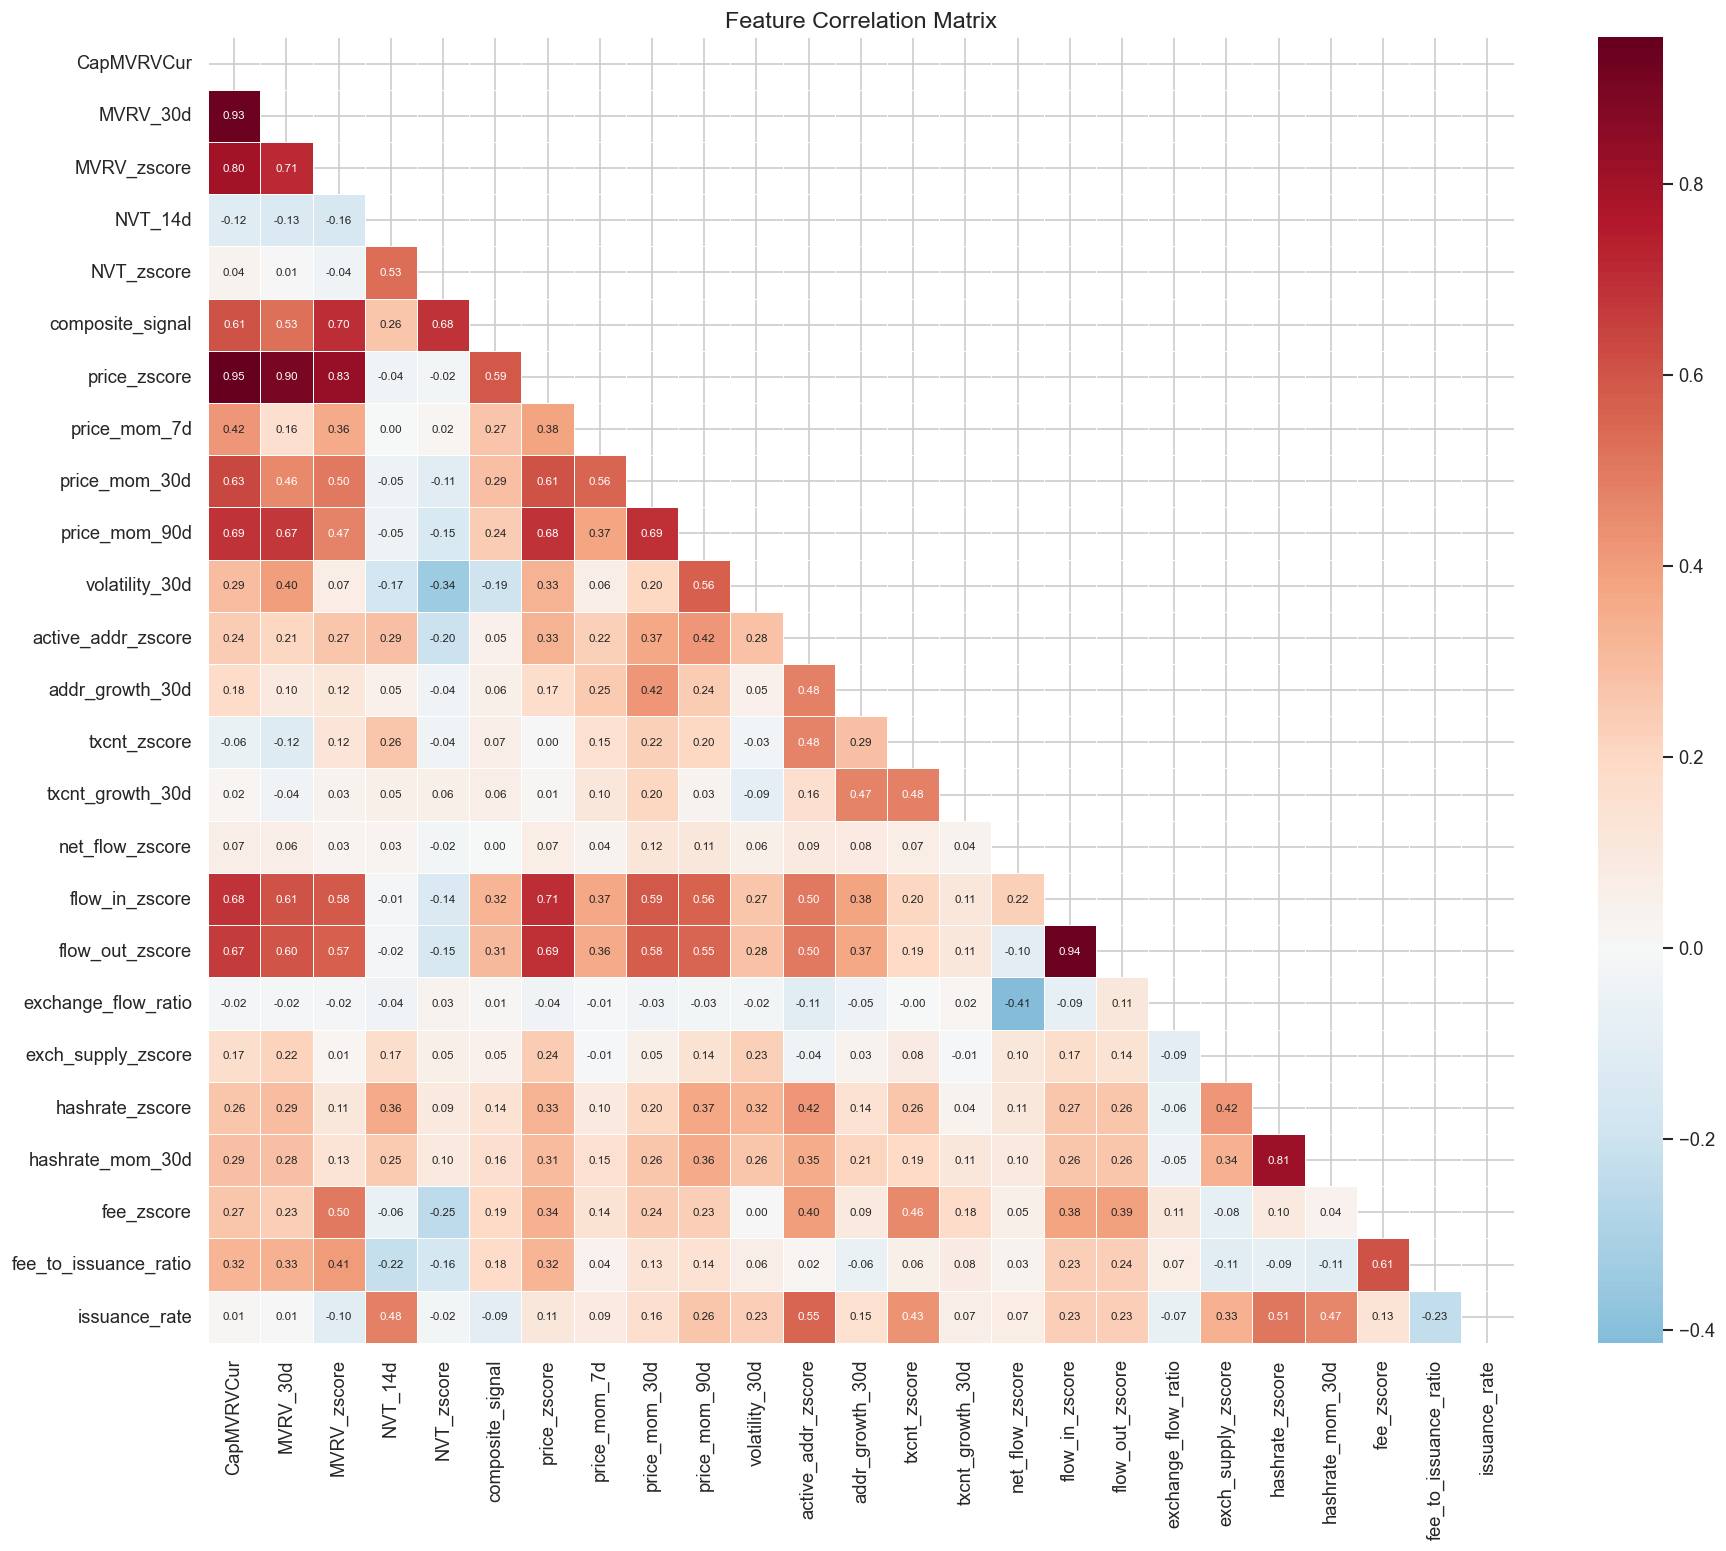


Highly correlated pairs (|r| > 0.8): 6
                      CapMVRVCur ↔ price_zscore                   r=+0.953
                  flow_in_zscore ↔ flow_out_zscore                r=+0.935
                      CapMVRVCur ↔ MVRV_30d                       r=+0.934
                        MVRV_30d ↔ price_zscore                   r=+0.903
                     MVRV_zscore ↔ price_zscore                   r=+0.826
                 hashrate_zscore ↔ hashrate_mom_30d               r=+0.810


In [29]:
# --- 4a. Correlation matrix ---
corr_pdf = model_df.select(FEATURE_COLS).to_pandas()
corr_matrix = corr_pdf.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, cmap="RdBu_r", center=0,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    square=True, linewidths=0.5, ax=ax,
)
ax.set_title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_feature_correlations.png", bbox_inches="tight")
plt.show()

# Flag highly correlated pairs (|r| > 0.8)
high_corr = []
for i in range(len(FEATURE_COLS)):
    for j in range(i + 1, len(FEATURE_COLS)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            high_corr.append((FEATURE_COLS[i], FEATURE_COLS[j], round(r, 3)))

print(f"\nHighly correlated pairs (|r| > 0.8): {len(high_corr)}")
for a, b, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {a:>30} ↔ {b:<30} r={r:+.3f}")

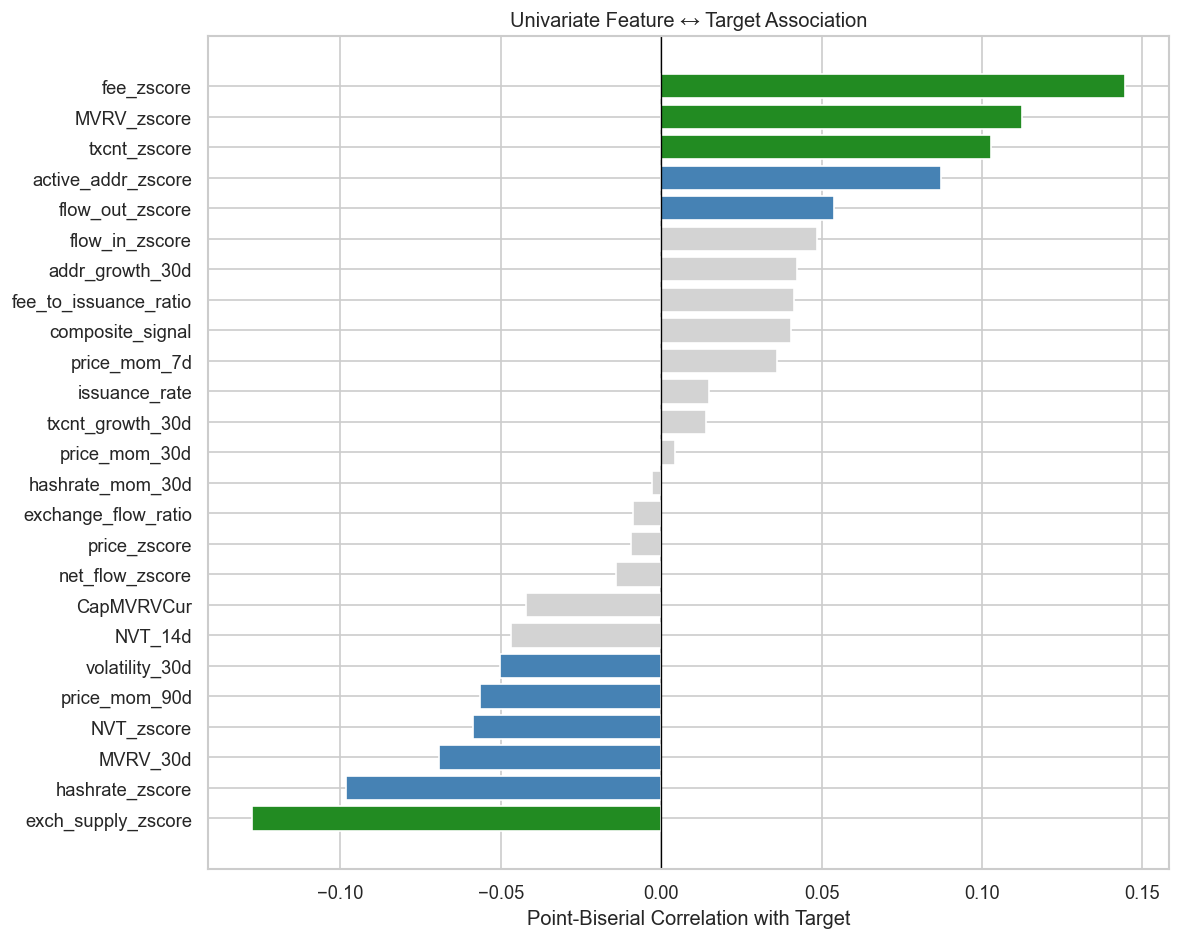

Top 10 features by |correlation| with target:


feature,corr_with_target,p_value,abs_corr
str,f64,f64,f64
"""fee_zscore""",0.1446,2.9126e-24,0.1446
"""exch_supply_zscore""",-0.1276,3.4236e-19,0.1276
"""MVRV_zscore""",0.1124,3.2367e-15,0.1124
"""txcnt_zscore""",0.1028,5.9261e-13,0.1028
"""hashrate_zscore""",-0.0983,5.5806e-12,0.0983
"""active_addr_zscore""",0.0873,9.7978e-10,0.0873
"""MVRV_30d""",-0.0692,0.000001,0.0692
"""NVT_zscore""",-0.0585,0.000043,0.0585
"""price_mom_90d""",-0.0565,0.000077,0.0565


In [30]:
# --- 4b. Univariate association: point-biserial correlation with target ---
target_arr = model_df["target"].to_numpy()

univariate_scores = []
for col in FEATURE_COLS:
    vals = model_df[col].to_numpy()
    r, p = stats.pointbiserialr(target_arr, vals)
    univariate_scores.append({"feature": col, "corr_with_target": round(r, 4), "p_value": p})

uni_df = pl.DataFrame(univariate_scores).sort("corr_with_target", descending=True)

fig, ax = plt.subplots(figsize=(10, 8))
uni_pdf = uni_df.to_pandas()
colours = ["forestgreen" if abs(r) > 0.1 else "steelblue" if abs(r) > 0.05 else "lightgrey"
           for r in uni_pdf["corr_with_target"]]
ax.barh(uni_pdf["feature"], uni_pdf["corr_with_target"], color=colours, edgecolor="white")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Point-Biserial Correlation with Target")
ax.set_title("Univariate Feature ↔ Target Association")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_univariate_association.png", bbox_inches="tight")
plt.show()

print("Top 10 features by |correlation| with target:")
uni_df.with_columns(pl.col("corr_with_target").abs().alias("abs_corr")).sort("abs_corr", descending=True).head(10)

## 5. Time-Series Cross-Validation Framework

Standard k-fold CV is invalid for time series (future data leaks into training). We use **expanding-window walk-forward** validation:

- Train on all data up to time *t*
- Test on the next chunk (e.g., 6 months)
- Advance *t* and repeat

This mirrors how a model would be used in practice: you retrain periodically on all history up to "now" and predict the next period.

In [31]:
# --- Prepare numpy arrays for sklearn ---
X = model_df.select(FEATURE_COLS).to_numpy()
y = model_df["target"].to_numpy()
dates_arr = model_df["date"].to_list()

# Time-series split: 5 folds, expanding training window
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print(f"Dataset size: {len(X):,} samples, {X.shape[1]} features")
print(f"Walk-forward splits: {N_SPLITS}")
print()
for i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"  Fold {i+1}: train {dates_arr[train_idx[0]]} to {dates_arr[train_idx[-1]]} "
          f"({len(train_idx):,} rows) | test {dates_arr[test_idx[0]]} to {dates_arr[test_idx[-1]]} "
          f"({len(test_idx):,} rows)")

Dataset size: 4,887 samples, 25 features
Walk-forward splits: 5

  Fold 1: train 2012-07-29 to 2014-10-23 (817 rows) | test 2014-10-24 to 2017-01-14 (814 rows)
  Fold 2: train 2012-07-29 to 2017-01-14 (1,631 rows) | test 2017-01-15 to 2019-04-08 (814 rows)
  Fold 3: train 2012-07-29 to 2019-04-08 (2,445 rows) | test 2019-04-09 to 2021-06-30 (814 rows)
  Fold 4: train 2012-07-29 to 2021-06-30 (3,259 rows) | test 2021-07-01 to 2023-09-22 (814 rows)
  Fold 5: train 2012-07-29 to 2023-09-22 (4,073 rows) | test 2023-09-23 to 2025-12-14 (814 rows)


## 6. Model Comparison

We compare several classifiers across all walk-forward folds:

| Model | Why |
|-------|-----|
| **Logistic Regression (L2)** | Simple baseline, interpretable coefficients |
| **Logistic Regression (L1 / LASSO)** | Automatic feature selection via sparsity |
| **Random Forest** | Captures non-linearities, feature importance |
| **Gradient Boosting** | Often top performer for tabular data |

All models receive standardised features (z-scored per training fold).

In [32]:
MODELS = {
    "Logistic (L2)": LogisticRegression(
        penalty="l2", C=1.0, max_iter=1000, solver="lbfgs", random_state=42
    ),
    "Logistic (L1/LASSO)": LogisticRegression(
        penalty="l1", C=1.0, max_iter=1000, solver="saga", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=6, min_samples_leaf=20, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        min_samples_leaf=20, subsample=0.8, random_state=42
    ),
}

# --- Walk-forward evaluation ---
fold_results = []  # stores per-fold metrics for each model
fold_predictions = {name: [] for name in MODELS}  # stores (date, y_true, y_pred, y_proba)

for fold_i, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Scale features (fit on train only)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    for name, model in MODELS.items():
        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)
        y_proba = model.predict_proba(X_test_s)[:, 1]

        fold_results.append({
            "model": name,
            "fold": fold_i + 1,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_proba),
            "test_start": str(dates_arr[test_idx[0]]),
            "test_end": str(dates_arr[test_idx[-1]]),
        })

        # Store predictions for later analysis
        fold_predictions[name].extend(
            zip(
                [dates_arr[i] for i in test_idx],
                y_test.tolist(),
                y_pred.tolist(),
                y_proba.tolist(),
            )
        )

results_df = pl.DataFrame(fold_results)
print("Walk-forward CV complete.")
results_df.head(8)

Walk-forward CV complete.


model,fold,accuracy,precision,recall,f1,roc_auc,test_start,test_end
str,i64,f64,f64,f64,f64,f64,str,str
"""Logistic (L2)""",1,0.523342,0.673077,0.366109,0.474255,0.538915,"""2014-10-24""","""2017-01-14"""
"""Logistic (L1/LASSO)""",1,0.513514,0.665323,0.345188,0.454545,0.517515,"""2014-10-24""","""2017-01-14"""
"""Random Forest""",1,0.640049,0.631954,0.926778,0.751484,0.676946,"""2014-10-24""","""2017-01-14"""
"""Gradient Boosting""",1,0.660934,0.644699,0.941423,0.765306,0.711378,"""2014-10-24""","""2017-01-14"""
"""Logistic (L2)""",2,0.477887,0.455764,0.433673,0.444444,0.546614,"""2017-01-15""","""2019-04-08"""
"""Logistic (L1/LASSO)""",2,0.482801,0.46049,0.431122,0.445323,0.549799,"""2017-01-15""","""2019-04-08"""
"""Random Forest""",2,0.72973,0.784768,0.604592,0.682997,0.807785,"""2017-01-15""","""2019-04-08"""
"""Gradient Boosting""",2,0.648649,0.666667,0.540816,0.597183,0.726932,"""2017-01-15""","""2019-04-08"""


In [33]:
# --- 6b. Aggregate metrics across folds ---
summary = (
    results_df
    .group_by("model")
    .agg([
        pl.col("accuracy").mean().alias("mean_accuracy"),
        pl.col("precision").mean().alias("mean_precision"),
        pl.col("recall").mean().alias("mean_recall"),
        pl.col("f1").mean().alias("mean_f1"),
        pl.col("roc_auc").mean().alias("mean_roc_auc"),
        pl.col("roc_auc").std().alias("std_roc_auc"),
    ])
    .sort("mean_roc_auc", descending=True)
)

print("Model Comparison (mean across walk-forward folds):")
print()
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'ROC AUC':>10} {'± std':>8}")
print("─" * 85)
for row in summary.iter_rows(named=True):
    print(f"{row['model']:<25} {row['mean_accuracy']:>10.3f} {row['mean_precision']:>10.3f} "
          f"{row['mean_recall']:>10.3f} {row['mean_f1']:>10.3f} {row['mean_roc_auc']:>10.3f} "
          f"±{row['std_roc_auc']:.3f}")

Model Comparison (mean across walk-forward folds):

Model                       Accuracy  Precision     Recall         F1    ROC AUC    ± std
─────────────────────────────────────────────────────────────────────────────────────
Gradient Boosting              0.587      0.626      0.573      0.527      0.625 ±0.088
Random Forest                  0.592      0.596      0.666      0.600      0.604 ±0.145
Logistic (L2)                  0.511      0.513      0.573      0.515      0.536 ±0.007
Logistic (L1/LASSO)            0.509      0.512      0.568      0.511      0.533 ±0.012


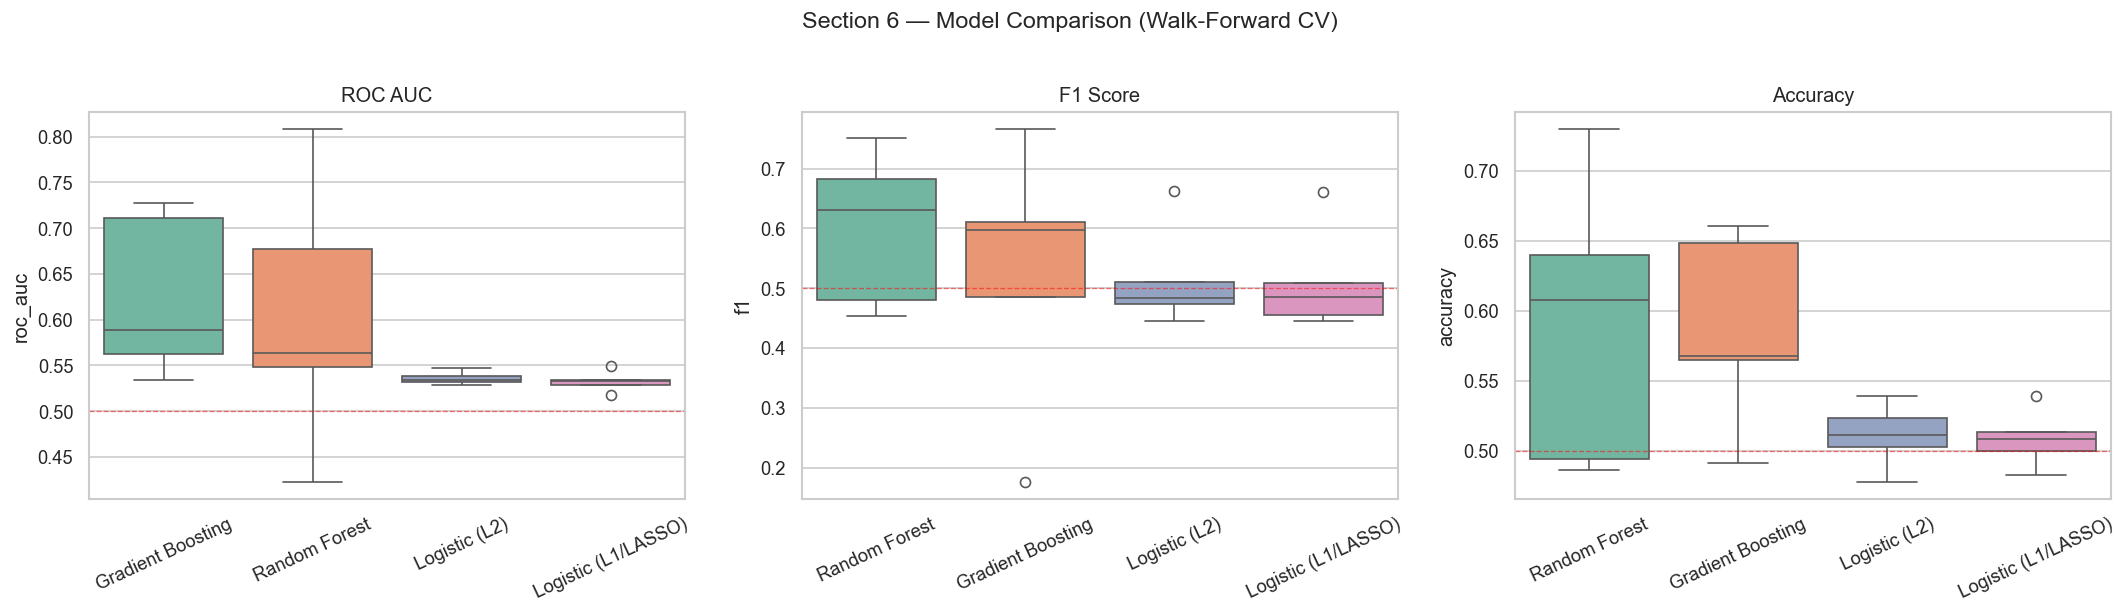

In [34]:
# --- 6c. Visualise model comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ["roc_auc", "f1", "accuracy"]
titles = ["ROC AUC", "F1 Score", "Accuracy"]

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    res_pdf = results_df.to_pandas()
    order = (
        res_pdf.groupby("model")[metric]
        .mean()
        .sort_values(ascending=False)
        .index.tolist()
    )
    sns.boxplot(data=res_pdf, x="model", y=metric, order=order, ax=ax, palette="Set2")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.axhline(0.5, color="red", ls="--", lw=0.8, alpha=0.5, label="Random baseline")

plt.suptitle("Section 6 — Model Comparison (Walk-Forward CV)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_comparison_boxplots.png", bbox_inches="tight")
plt.show()

## 7. Feature Selection

Three complementary approaches to identify the most predictive features:

1. **LASSO regularisation path** — which features survive increasing L1 penalty?
2. **Tree-based importance** — Gini / permutation importance from Random Forest & Gradient Boosting
3. **Consensus ranking** — combine all methods into a single feature importance ranking

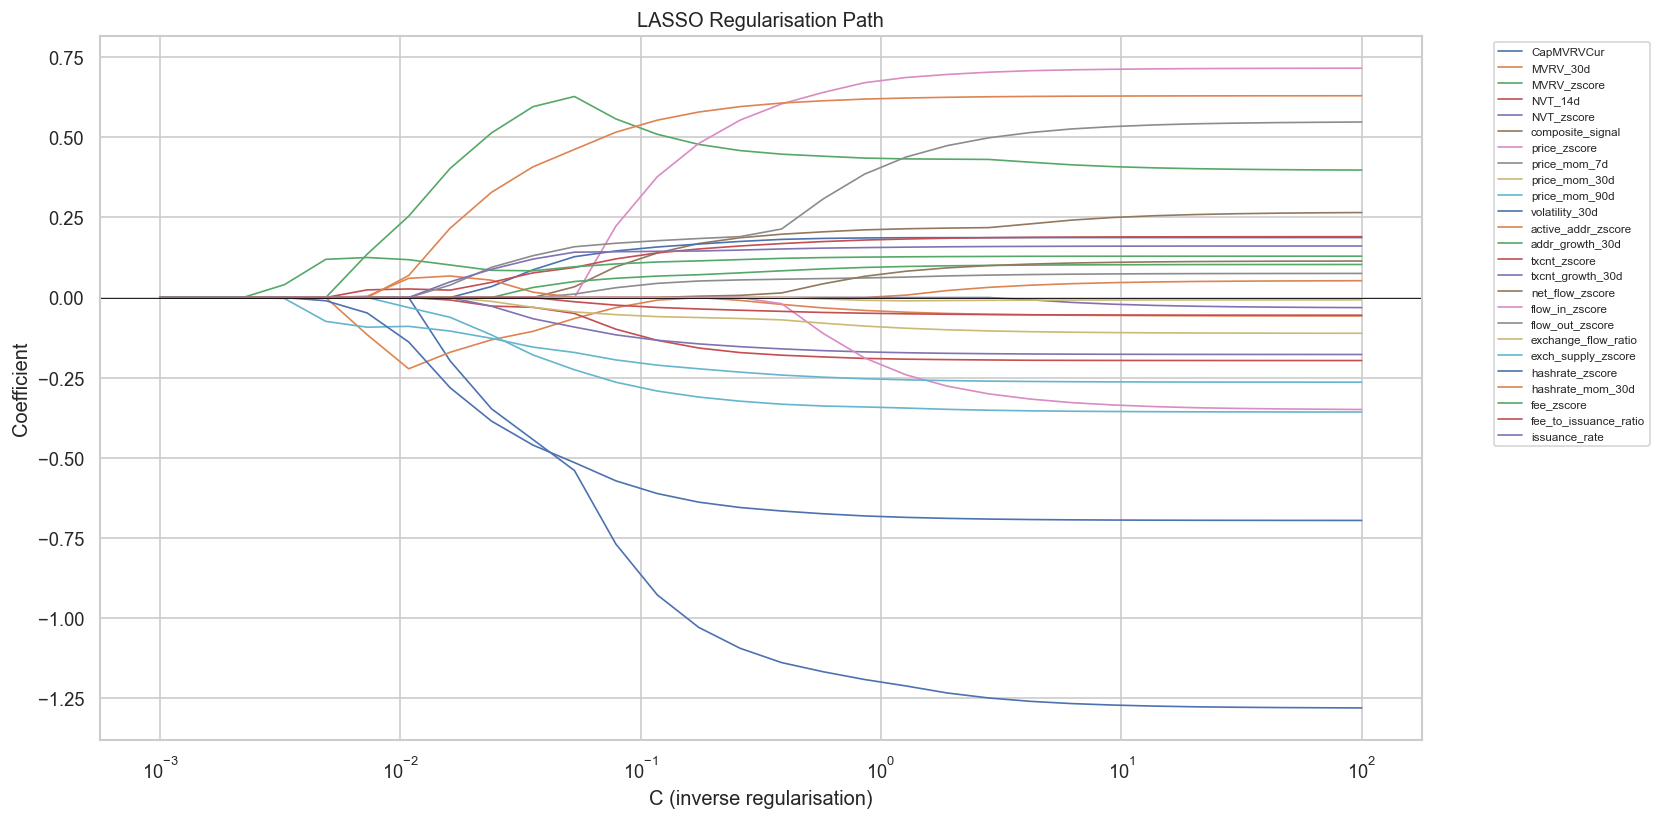


Features surviving LASSO at C=0.1: 20/25
                      CapMVRVCur: -0.8705
                 hashrate_zscore: -0.5970
                hashrate_mom_30d: +0.5396
                     MVRV_zscore: +0.5260
                    price_zscore: +0.3217
                   price_mom_90d: -0.2817
              exch_supply_zscore: -0.2050
                 flow_out_zscore: +0.1743
                  volatility_30d: +0.1532
                   issuance_rate: +0.1436
                    txcnt_zscore: +0.1326
                txcnt_growth_30d: -0.1272
                composite_signal: +0.1235
                         NVT_14d: -0.1209
                      fee_zscore: +0.1087
                 addr_growth_30d: +0.0645
             exchange_flow_ratio: -0.0573
                    price_mom_7d: +0.0393
           fee_to_issuance_ratio: -0.0284
                        MVRV_30d: -0.0165


In [35]:
# --- 7a. LASSO regularisation path ---
# Train on full dataset (for feature selection only; no prediction claims)
scaler_full = StandardScaler()
X_full_s = scaler_full.fit_transform(X)

C_values = np.logspace(-3, 2, 30)  # inverse regularisation strength
lasso_coefs = np.zeros((len(C_values), len(FEATURE_COLS)))

for i, C in enumerate(C_values):
    lr = LogisticRegression(penalty="l1", C=C, solver="saga", max_iter=2000, random_state=42)
    lr.fit(X_full_s, y)
    lasso_coefs[i] = lr.coef_[0]

fig, ax = plt.subplots(figsize=(14, 7))
for j, feat in enumerate(FEATURE_COLS):
    ax.plot(C_values, lasso_coefs[:, j], label=feat, linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("C (inverse regularisation)")
ax.set_ylabel("Coefficient")
ax.set_title("LASSO Regularisation Path")
ax.axhline(0, color="black", lw=0.5)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "lasso_regularisation_path.png", bbox_inches="tight")
plt.show()

# Features that survive at moderate regularisation (C=0.1)
lr_sparse = LogisticRegression(penalty="l1", C=0.1, solver="saga", max_iter=2000, random_state=42)
lr_sparse.fit(X_full_s, y)
surviving = [(feat, round(coef, 4)) for feat, coef in zip(FEATURE_COLS, lr_sparse.coef_[0]) if abs(coef) > 1e-6]
print(f"\nFeatures surviving LASSO at C=0.1: {len(surviving)}/{len(FEATURE_COLS)}")
for feat, coef in sorted(surviving, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:>30}: {coef:+.4f}")

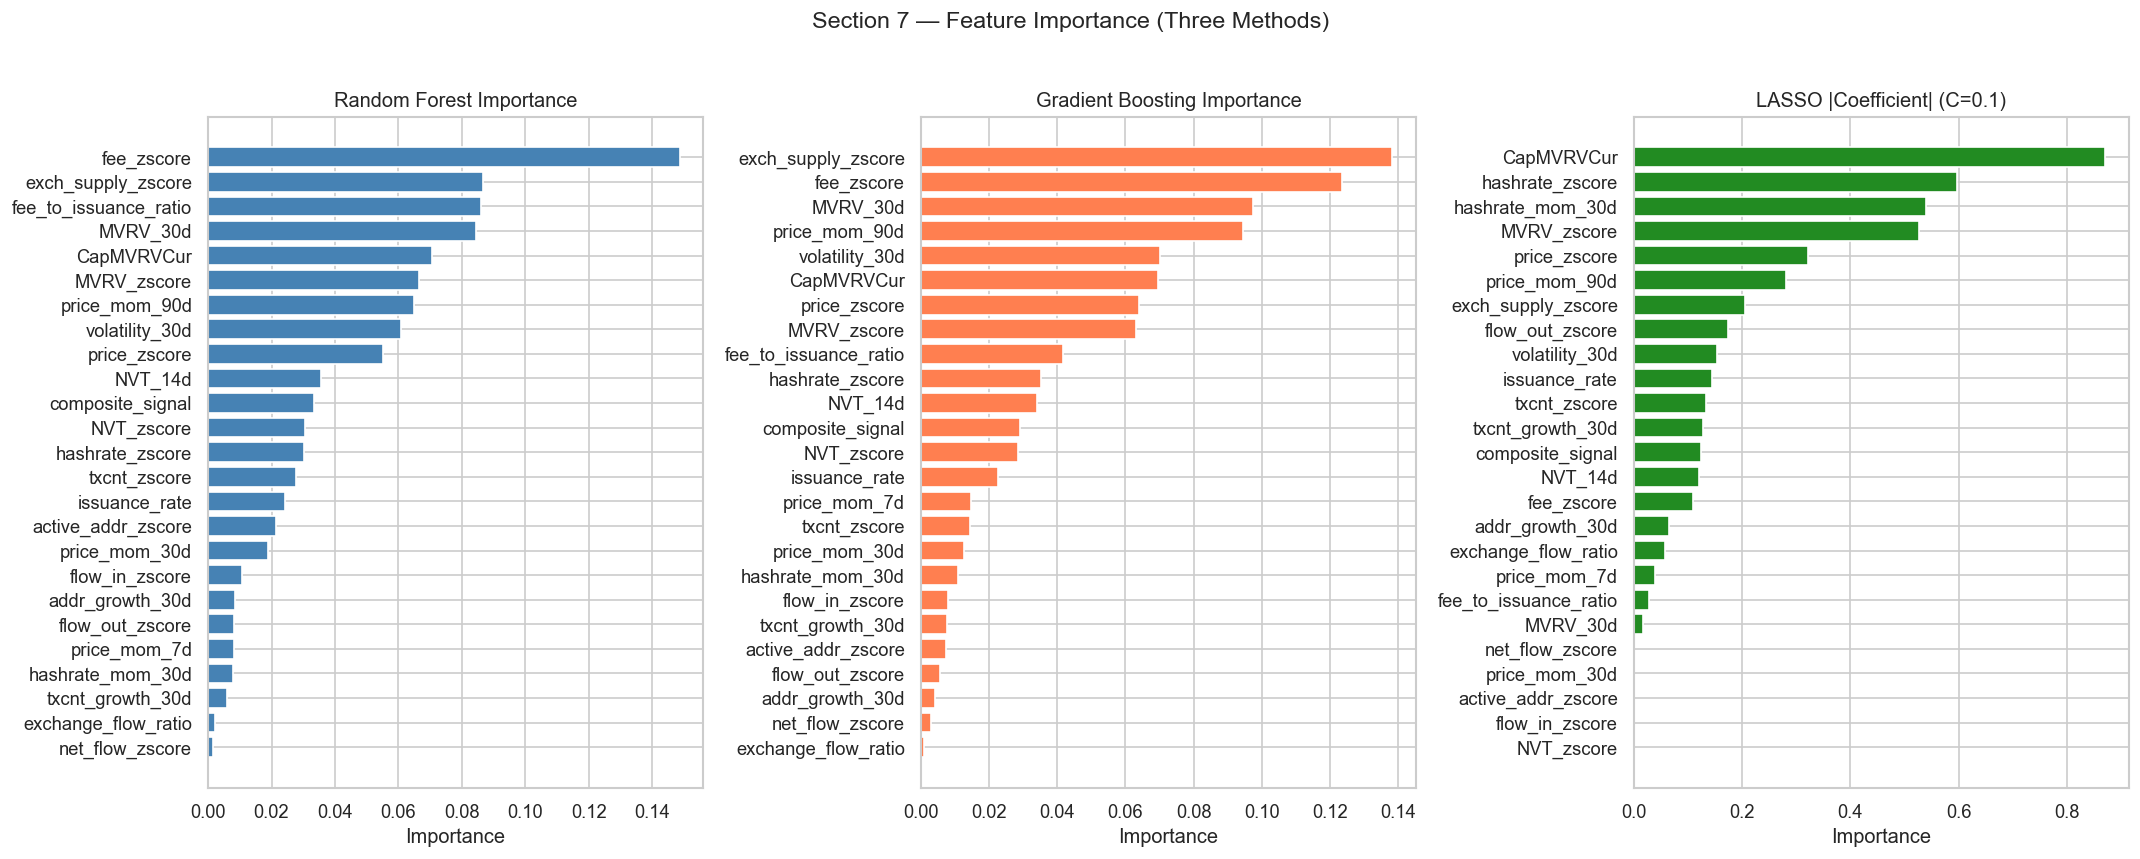

In [36]:
# --- 7b. Tree-based feature importance ---
# Retrain RF and GBM on full (scaled) data for importance extraction
rf_full = RandomForestClassifier(
    n_estimators=200, max_depth=6, min_samples_leaf=20, random_state=42, n_jobs=-1
)
rf_full.fit(X_full_s, y)
rf_importance = rf_full.feature_importances_

gbm_full = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    min_samples_leaf=20, subsample=0.8, random_state=42
)
gbm_full.fit(X_full_s, y)
gbm_importance = gbm_full.feature_importances_

# Combined view
importance_df = pl.DataFrame({
    "feature": FEATURE_COLS,
    "rf_importance": rf_importance,
    "gbm_importance": gbm_importance,
    "lasso_coef_abs": [abs(c) for c in lr_sparse.coef_[0]],
}).with_columns([
    # Normalise each to 0-1 scale
    (pl.col("rf_importance") / pl.col("rf_importance").max()).alias("rf_norm"),
    (pl.col("gbm_importance") / pl.col("gbm_importance").max()).alias("gbm_norm"),
    (pl.col("lasso_coef_abs") / pl.col("lasso_coef_abs").max().clip(lower_bound=1e-10)).alias("lasso_norm"),
])

# Consensus score: average of normalised importances
importance_df = importance_df.with_columns([
    ((pl.col("rf_norm") + pl.col("gbm_norm") + pl.col("lasso_norm")) / 3).alias("consensus_score")
]).sort("consensus_score", descending=True)

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

imp_pdf = importance_df.to_pandas()

for ax, col, title, color in [
    (axes[0], "rf_importance", "Random Forest Importance", "steelblue"),
    (axes[1], "gbm_importance", "Gradient Boosting Importance", "coral"),
    (axes[2], "lasso_coef_abs", "LASSO |Coefficient| (C=0.1)", "forestgreen"),
]:
    sorted_df = imp_pdf.sort_values(col, ascending=True)
    ax.barh(sorted_df["feature"], sorted_df[col], color=color, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Importance")

plt.suptitle("Section 7 — Feature Importance (Three Methods)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "feature_importance_comparison.png", bbox_inches="tight")
plt.show()

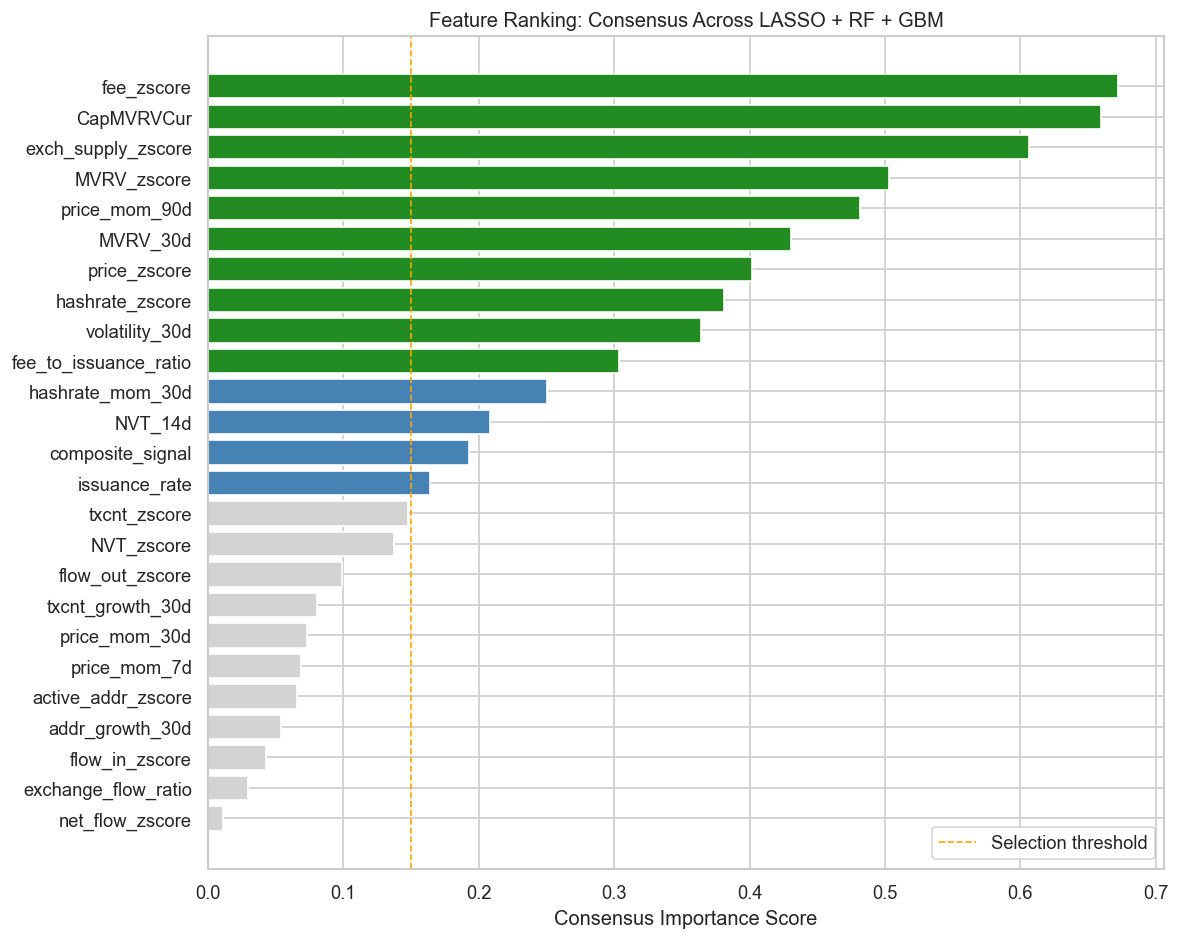


Selected 14 features (consensus >= 0.15):
                      fee_zscore | consensus=0.672 | RF=0.149 GBM=0.123 LASSO=0.1087
                      CapMVRVCur | consensus=0.659 | RF=0.071 GBM=0.070 LASSO=0.8705
              exch_supply_zscore | consensus=0.606 | RF=0.087 GBM=0.138 LASSO=0.2050
                     MVRV_zscore | consensus=0.503 | RF=0.067 GBM=0.063 LASSO=0.5260
                   price_mom_90d | consensus=0.482 | RF=0.065 GBM=0.095 LASSO=0.2817
                        MVRV_30d | consensus=0.430 | RF=0.084 GBM=0.097 LASSO=0.0165
                    price_zscore | consensus=0.401 | RF=0.055 GBM=0.064 LASSO=0.3217
                 hashrate_zscore | consensus=0.381 | RF=0.030 GBM=0.035 LASSO=0.5970
                  volatility_30d | consensus=0.364 | RF=0.061 GBM=0.070 LASSO=0.1532
           fee_to_issuance_ratio | consensus=0.304 | RF=0.086 GBM=0.042 LASSO=0.0284
                hashrate_mom_30d | consensus=0.250 | RF=0.008 GBM=0.011 LASSO=0.5396
                      

In [37]:
# --- 7c. Consensus feature ranking ---
fig, ax = plt.subplots(figsize=(10, 8))

cons_pdf = importance_df.sort("consensus_score", descending=False).to_pandas()
colours = ["forestgreen" if s > 0.3 else "steelblue" if s > 0.15 else "lightgrey"
           for s in cons_pdf["consensus_score"]]
ax.barh(cons_pdf["feature"], cons_pdf["consensus_score"], color=colours, edgecolor="white")
ax.set_xlabel("Consensus Importance Score")
ax.set_title("Feature Ranking: Consensus Across LASSO + RF + GBM")
ax.axvline(0.15, color="orange", ls="--", lw=1, label="Selection threshold")
ax.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "feature_consensus_ranking.png", bbox_inches="tight")
plt.show()

# --- Select top features ---
IMPORTANCE_THRESHOLD = 0.15
selected_features = (
    importance_df.filter(pl.col("consensus_score") >= IMPORTANCE_THRESHOLD)
    .sort("consensus_score", descending=True)
    ["feature"].to_list()
)

print(f"\nSelected {len(selected_features)} features (consensus >= {IMPORTANCE_THRESHOLD}):")
for f in selected_features:
    row = importance_df.filter(pl.col("feature") == f).row(0, named=True)
    print(f"  {f:>30} | consensus={row['consensus_score']:.3f} | "
          f"RF={row['rf_importance']:.3f} GBM={row['gbm_importance']:.3f} LASSO={row['lasso_coef_abs']:.4f}")

## 8. Reduced-Feature Model Evaluation

Re-run walk-forward CV using only the selected features. This tests whether the pruned model retains (or improves) predictive performance while reducing complexity and overfitting risk.

In [38]:
# --- 8a. Walk-forward CV with selected features ---
X_sel = model_df.select(selected_features).to_numpy()

reduced_results = []
reduced_predictions = {name: [] for name in MODELS}

for fold_i, (train_idx, test_idx) in enumerate(tscv.split(X_sel)):
    X_train, X_test = X_sel[train_idx], X_sel[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    for name, model in MODELS.items():
        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)
        y_proba = model.predict_proba(X_test_s)[:, 1]

        reduced_results.append({
            "model": name,
            "fold": fold_i + 1,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_test, y_proba),
        })

        reduced_predictions[name].extend(
            zip(
                [dates_arr[i] for i in test_idx],
                y_test.tolist(),
                y_pred.tolist(),
                y_proba.tolist(),
            )
        )

reduced_df = pl.DataFrame(reduced_results)

# --- Compare full vs reduced feature sets ---
full_summary = (
    results_df.group_by("model").agg([
        pl.col("roc_auc").mean().alias("full_auc"),
        pl.col("f1").mean().alias("full_f1"),
    ])
)
reduced_summary = (
    reduced_df.group_by("model").agg([
        pl.col("roc_auc").mean().alias("reduced_auc"),
        pl.col("f1").mean().alias("reduced_f1"),
    ])
)

comparison = full_summary.join(reduced_summary, on="model").with_columns([
    (pl.col("reduced_auc") - pl.col("full_auc")).alias("auc_delta"),
    (pl.col("reduced_f1") - pl.col("full_f1")).alias("f1_delta"),
]).sort("reduced_auc", descending=True)

print(f"Full feature set: {len(FEATURE_COLS)} features | Reduced: {len(selected_features)} features")
print()
print(f"{'Model':<25} {'Full AUC':>10} {'Red. AUC':>10} {'Δ AUC':>8} {'Full F1':>10} {'Red. F1':>10} {'Δ F1':>8}")
print("─" * 90)
for row in comparison.iter_rows(named=True):
    print(f"{row['model']:<25} {row['full_auc']:>10.3f} {row['reduced_auc']:>10.3f} "
          f"{row['auc_delta']:>+8.3f} {row['full_f1']:>10.3f} {row['reduced_f1']:>10.3f} "
          f"{row['f1_delta']:>+8.3f}")

Full feature set: 25 features | Reduced: 14 features

Model                       Full AUC   Red. AUC    Δ AUC    Full F1    Red. F1     Δ F1
──────────────────────────────────────────────────────────────────────────────────────────
Gradient Boosting              0.625      0.617   -0.008      0.527      0.554   +0.027
Random Forest                  0.604      0.611   +0.007      0.600      0.605   +0.005
Logistic (L1/LASSO)            0.533      0.571   +0.038      0.511      0.474   -0.037
Logistic (L2)                  0.536      0.570   +0.034      0.515      0.470   -0.045


In [39]:
# --- 8b. Identify the best model ---
best_model_name = comparison.row(0, named=True)["model"]
print(f"Best model (by reduced-feature AUC): {best_model_name}")
print(f"Selected features ({len(selected_features)}): {selected_features}")

# Build final predictions dataframe from the best model's walk-forward predictions
best_preds = reduced_predictions[best_model_name]
pred_df = pl.DataFrame({
    "date": [p[0] for p in best_preds],
    "y_true": [p[1] for p in best_preds],
    "y_pred": [p[2] for p in best_preds],
    "y_proba": [p[3] for p in best_preds],
}).sort("date")

print(f"\nOut-of-sample predictions: {len(pred_df):,} days")
print(f"Date range: {pred_df['date'].min()} to {pred_df['date'].max()}")
print(f"\nClassification Report (walk-forward, out-of-sample):")
print(classification_report(
    pred_df["y_true"].to_numpy(),
    pred_df["y_pred"].to_numpy(),
    target_names=["Unfavourable", "Favourable"],
))

Best model (by reduced-feature AUC): Gradient Boosting
Selected features (14): ['fee_zscore', 'CapMVRVCur', 'exch_supply_zscore', 'MVRV_zscore', 'price_mom_90d', 'MVRV_30d', 'price_zscore', 'hashrate_zscore', 'volatility_30d', 'fee_to_issuance_ratio', 'hashrate_mom_30d', 'NVT_14d', 'composite_signal', 'issuance_rate']

Out-of-sample predictions: 4,070 days
Date range: 2014-10-24 to 2025-12-14

Classification Report (walk-forward, out-of-sample):
              precision    recall  f1-score   support

Unfavourable       0.60      0.55      0.57      2081
  Favourable       0.57      0.63      0.60      1989

    accuracy                           0.59      4070
   macro avg       0.59      0.59      0.59      4070
weighted avg       0.59      0.59      0.59      4070



## 9. DCA Integration: Model-Driven Dynamic Allocation

Use the best model’s probability output to drive dynamic DCA allocation:
- High predicted probability of favourable window → allocate more
- Low probability → allocate less
- Budget remains neutral (rescaled per window)

This replaces the hand-crafted z-score thresholds from Part 2 with a learned model signal.

In [40]:
# --- 9a. Build the model-driven DCA signal ---
# Join predictions back to the price data
dca_df = (
    model_df.select(["date", "PriceUSD"])
    .join(pred_df.select(["date", "y_proba"]), on="date", how="inner")
    .sort("date")
)

# Convert probability to multiplier:
# p > 0.6 -> favourable -> buy more (1.5x)
# p < 0.4 -> unfavourable -> buy less (0.5x)
# else -> neutral (1.0x)
dca_df = dca_df.with_columns([
    pl.when(pl.col("y_proba") > 0.6).then(1.5)
    .when(pl.col("y_proba") < 0.4).then(0.5)
    .otherwise(1.0)
    .alias("model_multiplier")
])

print(f"DCA signal data: {len(dca_df):,} days")
print(f"Multiplier distribution:")
print(dca_df.group_by("model_multiplier").agg(pl.len().alias("n")).sort("model_multiplier"))

DCA signal data: 4,070 days
Multiplier distribution:
shape: (3, 2)
┌──────────────────┬──────┐
│ model_multiplier ┆ n    │
│ ---              ┆ ---  │
│ f64              ┆ u32  │
╞══════════════════╪══════╡
│ 0.5              ┆ 1607 │
│ 1.0              ┆ 532  │
│ 1.5              ┆ 1931 │
└──────────────────┴──────┘


In [41]:
# --- 9b. Rolling 12-month DCA backtest: model-driven vs uniform ---
def generate_rolling_windows(
    min_date: date, max_date: date, window_months: int = 12, step_months: int = 1
) -> list[tuple[date, date]]:
    windows = []
    d = min_date
    while True:
        end_year = d.year + (d.month + window_months - 1) // 12
        end_month = (d.month + window_months - 1) % 12 + 1
        end_d = date(end_year, end_month, min(d.day, 28))
        if end_d > max_date:
            break
        windows.append((d, end_d))
        step_year = d.year + (d.month + step_months - 1) // 12
        step_month = (d.month + step_months - 1) % 12 + 1
        d = date(step_year, step_month, min(d.day, 28))
    return windows


valid_dates = dca_df["date"].to_list()
dca_windows = generate_rolling_windows(valid_dates[0], valid_dates[-1])
print(f"Rolling windows: {len(dca_windows)}")

dca_results = []
for ws, we in dca_windows:
    window = dca_df.filter((pl.col("date") >= ws) & (pl.col("date") <= we)).sort("date")
    if len(window) < 30:
        continue

    prices = window["PriceUSD"].to_list()
    multipliers = window["model_multiplier"].to_list()
    n = len(prices)

    # Uniform DCA
    uniform_total = BASE_BUY_USD * n
    uniform_btc = sum(BASE_BUY_USD / p for p in prices)

    # Model-driven DCA (budget-neutral)
    raw_spend = [BASE_BUY_USD * m for m in multipliers]
    raw_total = sum(raw_spend)
    scale = uniform_total / raw_total if raw_total > 0 else 1.0
    dynamic_btc = sum((BASE_BUY_USD * m * scale) / p for m, p in zip(multipliers, prices))

    dca_results.append({
        "window_start": ws,
        "window_end": we,
        "n_days": n,
        "uniform_btc": uniform_btc,
        "dynamic_btc": dynamic_btc,
        "btc_advantage_pct": (dynamic_btc / uniform_btc - 1) * 100,
        "uniform_avg_cost": uniform_total / uniform_btc,
        "dynamic_avg_cost": uniform_total / dynamic_btc,
    })

dca_res_df = pl.DataFrame(dca_results)

adv = dca_res_df["btc_advantage_pct"]
print(f"\nModel-Driven Dynamic DCA Results ({len(dca_res_df)} windows):")
print(f"  Mean BTC advantage:   {adv.mean():+.3f}%")
print(f"  Median BTC advantage: {adv.median():+.3f}%")
print(f"  Win rate:             {(adv > 0).mean()*100:.1f}%")
print(f"  Std:                  {adv.std():.3f}%")
print(f"  Range:                [{adv.min():+.2f}%, {adv.max():+.2f}%]")

Rolling windows: 122

Model-Driven Dynamic DCA Results (122 windows):
  Mean BTC advantage:   +3.115%
  Median BTC advantage: +1.859%
  Win rate:             75.4%
  Std:                  5.037%
  Range:                [-6.61%, +19.30%]


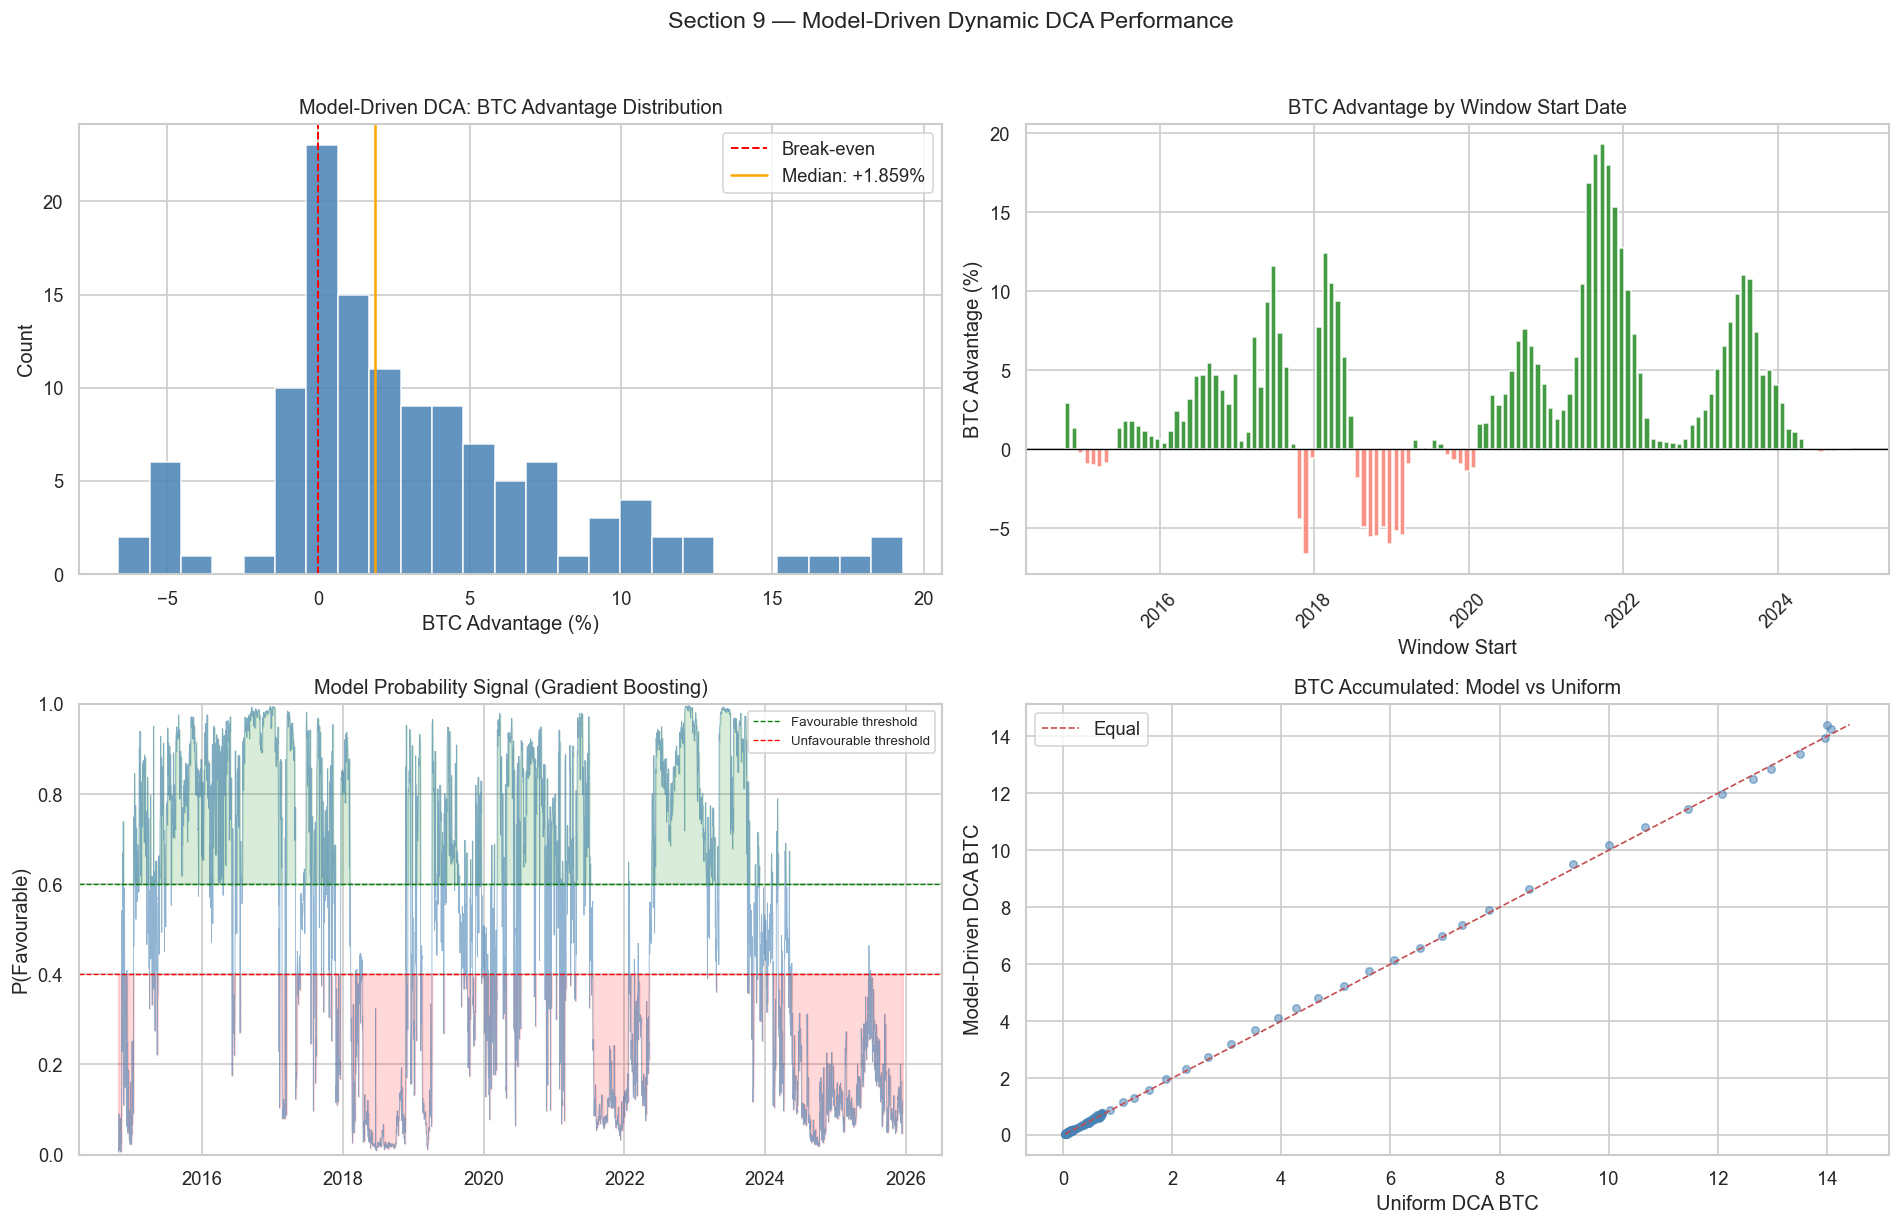

In [42]:
# --- 9c. Visualise DCA results ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

adv_vals = dca_res_df["btc_advantage_pct"].to_numpy()

# (1) Histogram of BTC advantage
ax = axes[0, 0]
ax.hist(adv_vals, bins=25, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", ls="--", lw=1.2, label="Break-even")
ax.axvline(np.median(adv_vals), color="orange", ls="-", lw=1.5,
           label=f"Median: {np.median(adv_vals):+.3f}%")
ax.set_xlabel("BTC Advantage (%)")
ax.set_ylabel("Count")
ax.set_title("Model-Driven DCA: BTC Advantage Distribution")
ax.legend()

# (2) Advantage over time
ax = axes[0, 1]
starts = dca_res_df["window_start"].to_list()
ax.bar(starts, adv_vals,
       color=["forestgreen" if v > 0 else "salmon" for v in adv_vals],
       width=25, alpha=0.85)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Window Start")
ax.set_ylabel("BTC Advantage (%)")
ax.set_title("BTC Advantage by Window Start Date")
ax.tick_params(axis="x", rotation=45)

# (3) Probability signal over time
ax = axes[1, 0]
sig_pdf = dca_df.select(["date", "y_proba"]).to_pandas()
ax.plot(sig_pdf["date"], sig_pdf["y_proba"], color="steelblue", lw=0.5, alpha=0.6)
ax.axhline(0.6, color="green", ls="--", lw=0.8, label="Favourable threshold")
ax.axhline(0.4, color="red", ls="--", lw=0.8, label="Unfavourable threshold")
ax.fill_between(sig_pdf["date"], 0.6, sig_pdf["y_proba"].clip(lower=0.6),
                color="green", alpha=0.15)
ax.fill_between(sig_pdf["date"], 0.4, sig_pdf["y_proba"].clip(upper=0.4),
                color="red", alpha=0.15)
ax.set_ylabel("P(Favourable)")
ax.set_title(f"Model Probability Signal ({best_model_name})")
ax.legend(fontsize=8)
ax.set_ylim(0, 1)

# (4) Scatter: uniform vs dynamic BTC
ax = axes[1, 1]
u_btc = dca_res_df["uniform_btc"].to_numpy()
d_btc = dca_res_df["dynamic_btc"].to_numpy()
ax.scatter(u_btc, d_btc, alpha=0.5, s=20, color="steelblue")
lims = [min(u_btc.min(), d_btc.min()), max(u_btc.max(), d_btc.max())]
ax.plot(lims, lims, "r--", lw=1, label="Equal")
ax.set_xlabel("Uniform DCA BTC")
ax.set_ylabel("Model-Driven DCA BTC")
ax.set_title("BTC Accumulated: Model vs Uniform")
ax.legend()

plt.suptitle("Section 9 — Model-Driven Dynamic DCA Performance", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_driven_dca_results.png", bbox_inches="tight")
plt.show()

## 9.5 Dynamic Strength Tuning

The **dynamic strength** parameter controls how aggressively the strategy deviates from uniform DCA based on the model's probability output. Using the exponential multiplier from the assignment template:

$$\text{multiplier} = \exp\bigl((\text{proba} - 0.5) \times 2 \times \text{strength}\bigr)$$

| Strength | P=0.8 multiplier | P=0.2 multiplier | Behaviour |
|----------|-------------------|-------------------|-----------|
| 0.25 | 1.16× | 0.86× | Very conservative |
| 1.0 | 1.82× | 0.55× | Moderate |
| 2.0 | 3.32× | 0.30× | Aggressive |
| 3.0 | 6.05× | 0.17× | Very aggressive |

**Scoring aligned with assignment grading** (`backtest_template.py`):

$$\text{score} = 0.5 \times \text{win\_rate\%} + 0.5 \times \text{exp\_decay\_percentile\%}$$

Where:
- **win_rate%** = % of windows where `dynamic_percentile > uniform_percentile`
- **exp_decay_percentile%** = exponential-decay weighted average (decay=0.9) of the **absolute** `dynamic_percentile` (not excess over uniform)

Higher strength → more aggressive bets → higher mean advantage but **lower absolute SPD percentile** when wrong, which the exp-decay term penalises heavily.

In [ ]:
# --- 9.5a. Dynamic strength grid search ---
# Faithfully replicates the template's weight allocation + SPD scoring:
# 1. exponential_multiplier (model_development_template.py)
# 2. allocate_sequential_stable (model_development_template.py)
# 3. SPD percentile via weighted inv_price (prelude_template.py compute_cycle_spd)
# 4. score = 0.5 * win_rate% + 0.5 * exp_decay_percentile% (backtest_template.py)

def exponential_multiplier(proba: np.ndarray, strength: float) -> np.ndarray:
    """Template-matching: exp((p - 0.5) * 2 * strength), clipped to [-3, 3]."""
    signal = (proba - 0.5) * 2
    adjustment = np.clip(signal * strength, -3, 3)
    mult = np.exp(adjustment)
    return np.where(np.isfinite(mult), mult, 1.0)


def _compute_stable_signal(raw: np.ndarray) -> float:
    """Replicate _compute_stable_signal from model_development_template.py.

    Returns the signal for the last element: raw[-1] / mean(raw).
    """
    n = len(raw)
    if n == 0:
        return 1.0
    if n == 1:
        return 1.0
    running_mean = raw.mean()
    if running_mean == 0 or not np.isfinite(running_mean):
        return 1.0
    signal = raw[-1] / running_mean
    return signal if np.isfinite(signal) else 1.0


def allocate_sequential_stable(raw: np.ndarray) -> np.ndarray:
    """Replicate allocate_sequential_stable from model_development_template.py.

    Backtest mode (n_past = n, no locked_weights):
    - For each day i: w[i] = signal(raw[0:i+1]) * base_weight
    - signal = raw[i] / mean(raw[0:i+1])
    - Last day absorbs remainder to guarantee sum = 1.0
    - Past weights scaled down if they exceed budget
    """
    n = len(raw)
    if n == 0:
        return np.array([])
    if n == 1:
        return np.array([1.0])

    base_weight = 1.0 / n
    w = np.zeros(n)

    for i in range(n):
        signal = _compute_stable_signal(raw[: i + 1])
        w[i] = signal * base_weight

    # Scale past weights if they exceed budget (n_past/n = 1.0 in backtest)
    past_sum = w.sum()
    if past_sum > 1.0 + 1e-10:
        w *= 1.0 / past_sum

    # Last day absorbs remainder
    w[-1] = max(1.0 - w[:-1].sum(), 0)

    return w


def compute_spd_percentile(prices: np.ndarray, weights: np.ndarray) -> tuple[float, float]:
    """Replicate SPD percentile from prelude_template.py compute_cycle_spd.

    Returns (dynamic_percentile, uniform_percentile).
    """
    inv_price = 1e8 / prices  # sats per dollar
    min_spd = inv_price.min()
    max_spd = inv_price.max()
    span = max_spd - min_spd

    uniform_spd = inv_price.mean()          # equal weight = mean
    dynamic_spd = (weights * inv_price).sum()  # weighted SPD

    if span > 0:
        uniform_pct = (uniform_spd - min_spd) / span * 100
        dynamic_pct = (dynamic_spd - min_spd) / span * 100
    else:
        uniform_pct = 50.0
        dynamic_pct = 50.0

    return dynamic_pct, uniform_pct


def run_dca_backtest_with_strength(
    dca_data: pl.DataFrame,
    windows: list[tuple[date, date]],
    strength: float,
) -> dict:
    """Run full DCA backtest replicating the template's allocation + scoring.

    Weight pipeline (per window):
      1. base = 1/n for each day
      2. dyn = exponential_multiplier(proba, strength)
      3. raw = base * dyn
      4. weights = allocate_sequential_stable(raw)  # lock-on-compute stability
      5. SPD percentile = weighted inv_price position on [min, max] range

    Scoring (matches backtest_template.py):
      score = 0.5 * win_rate% + 0.5 * exp_decay_percentile%
    """
    results = []
    for ws, we in windows:
        window = dca_data.filter(
            (pl.col("date") >= ws) & (pl.col("date") <= we)
        ).sort("date")
        if len(window) < 30:
            continue

        prices = window["PriceUSD"].to_numpy()
        probas = window["y_proba"].to_numpy()
        n = len(prices)

        # --- Replicate template weight computation ---
        base = np.ones(n) / n
        # Handle missing/zero probas (template treats < 1e-6 as 0.5 = neutral)
        probas_clean = np.where(probas < 1e-6, 0.5, probas)
        dyn = exponential_multiplier(probas_clean, strength)
        raw = base * dyn

        # Stable allocation (matches allocate_sequential_stable in backtest mode)
        weights = allocate_sequential_stable(raw)

        # --- Replicate template SPD percentile ---
        dynamic_pct, uniform_pct = compute_spd_percentile(prices, weights)

        # Also compute BTC advantage for reference
        uniform_btc = np.sum(1.0 / prices)  # proportional to uniform DCA BTC
        dynamic_btc = np.sum(weights * n / prices)  # weights sum to 1, rescale
        advantage = (dynamic_btc / uniform_btc - 1) * 100 if uniform_btc > 0 else 0

        results.append({
            "advantage": advantage,
            "pct_dynamic": dynamic_pct,
            "pct_uniform": uniform_pct,
        })

    advantages = np.array([r["advantage"] for r in results])
    pct_dyn = np.array([r["pct_dynamic"] for r in results])
    pct_uni = np.array([r["pct_uniform"] for r in results])

    # Win rate: % of windows where dynamic beats uniform (matches template)
    win_rate_pct = (pct_dyn > pct_uni).mean() * 100

    # Exp-decay weighted average of ABSOLUTE dynamic percentile
    # decay=0.9 matching prelude_template.py backtest_dynamic_dca()
    n_windows = len(pct_dyn)
    decay = 0.9
    decay_weights = np.array([decay ** (n_windows - 1 - i) for i in range(n_windows)])
    decay_weights /= decay_weights.sum()
    exp_decay_percentile = np.sum(decay_weights * pct_dyn)

    # Assignment score: 0.5 * win_rate% + 0.5 * exp_decay_percentile%
    score = 0.5 * win_rate_pct + 0.5 * exp_decay_percentile

    # Excess metrics for analysis
    excess_pct = pct_dyn - pct_uni
    exp_decay_excess = np.sum(decay_weights * excess_pct)

    return {
        "strength": strength,
        "win_rate_pct": win_rate_pct,
        "exp_decay_percentile": exp_decay_percentile,
        "score": score,
        "mean_advantage": advantages.mean(),
        "median_advantage": np.median(advantages),
        "std_advantage": advantages.std(),
        "exp_decay_excess_pct": exp_decay_excess,
        "mean_pct_dynamic": pct_dyn.mean(),
        "mean_pct_uniform": pct_uni.mean(),
        "n_windows": len(results),
    }


# --- Grid search ---
STRENGTH_GRID = np.concatenate([
    np.arange(0.1, 0.5, 0.1),   # conservative range
    np.arange(0.5, 2.0, 0.25),  # moderate range
    np.arange(2.0, 4.1, 0.5),   # aggressive range
])

# Reuse dca_df and windows from Section 9
strength_results = []
for s in STRENGTH_GRID:
    result = run_dca_backtest_with_strength(dca_df, dca_windows, strength=s)
    strength_results.append(result)

strength_df = pl.DataFrame(strength_results)

# Find optimal
best_row = strength_df.sort("score", descending=True).row(0, named=True)
best_by_winrate = strength_df.sort("win_rate_pct", descending=True).row(0, named=True)
best_by_advantage = strength_df.sort("mean_advantage", descending=True).row(0, named=True)

print(f"Dynamic Strength Grid Search ({len(STRENGTH_GRID)} values)")
print(f"Scoring: score = 0.5 × win_rate% + 0.5 × exp_decay_percentile% (decay=0.9)")
print(f"Weight allocation: allocate_sequential_stable (matching template)")
print("=" * 110)
print(f"{'Strength':>10} {'Win%':>8} {'ExpDecay%':>10} {'Score%':>8} │ "
      f"{'DynPct%':>8} {'UniPct%':>8} {'MeanAdv%':>10} {'Std%':>8}")
print("─" * 110)
for row in strength_df.iter_rows(named=True):
    marker = " ◀ BEST" if row["strength"] == best_row["strength"] else ""
    print(f"{row['strength']:>10.2f} {row['win_rate_pct']:>8.1f} {row['exp_decay_percentile']:>10.2f} "
          f"{row['score']:>8.2f} │ {row['mean_pct_dynamic']:>8.2f} {row['mean_pct_uniform']:>8.2f} "
          f"{row['mean_advantage']:>+10.3f} {row['std_advantage']:>8.3f}{marker}")

print()
print(f"Optimal by assignment score: strength={best_row['strength']:.2f} "
      f"(score={best_row['score']:.2f}%, win={best_row['win_rate_pct']:.1f}%, "
      f"exp_decay={best_row['exp_decay_percentile']:.2f}%)")
print(f"Optimal by win rate:         strength={best_by_winrate['strength']:.2f} "
      f"(win={best_by_winrate['win_rate_pct']:.1f}%)")
print(f"Optimal by mean advantage:   strength={best_by_advantage['strength']:.2f} "
      f"(adv={best_by_advantage['mean_advantage']:+.3f}%)")

Dynamic Strength Grid Search (15 values)
Scoring: score = 0.5 × win_rate% + 0.5 × exp_decay_percentile% (decay=0.9)
  Strength     Win%  ExpDecay%   Score% │   MeanAdv%    MedAdv%     Std%  ExcDecay%
─────────────────────────────────────────────────────────────────────────────────────────────────────────
      0.10     73.8      38.20    55.98 │     +0.495     +0.385    0.703     +0.172
      0.20     73.8      38.37    56.07 │     +0.993     +0.746    1.408     +0.347
      0.30     73.8      38.55    56.16 │     +1.493     +1.104    2.114     +0.524
      0.40     73.8      38.73    56.25 │     +1.993     +1.508    2.820     +0.704
      0.50     73.8      38.91    56.34 │     +2.491     +1.874    3.523     +0.885
      0.75     74.6      39.36    56.98 │     +3.721     +2.592    5.267     +1.338
      1.00     73.8      39.81    56.79 │     +4.911     +3.296    6.970     +1.787
      1.25     73.8      40.25    57.01 │     +6.040     +3.993    8.604     +2.221
      1.50     74.6   

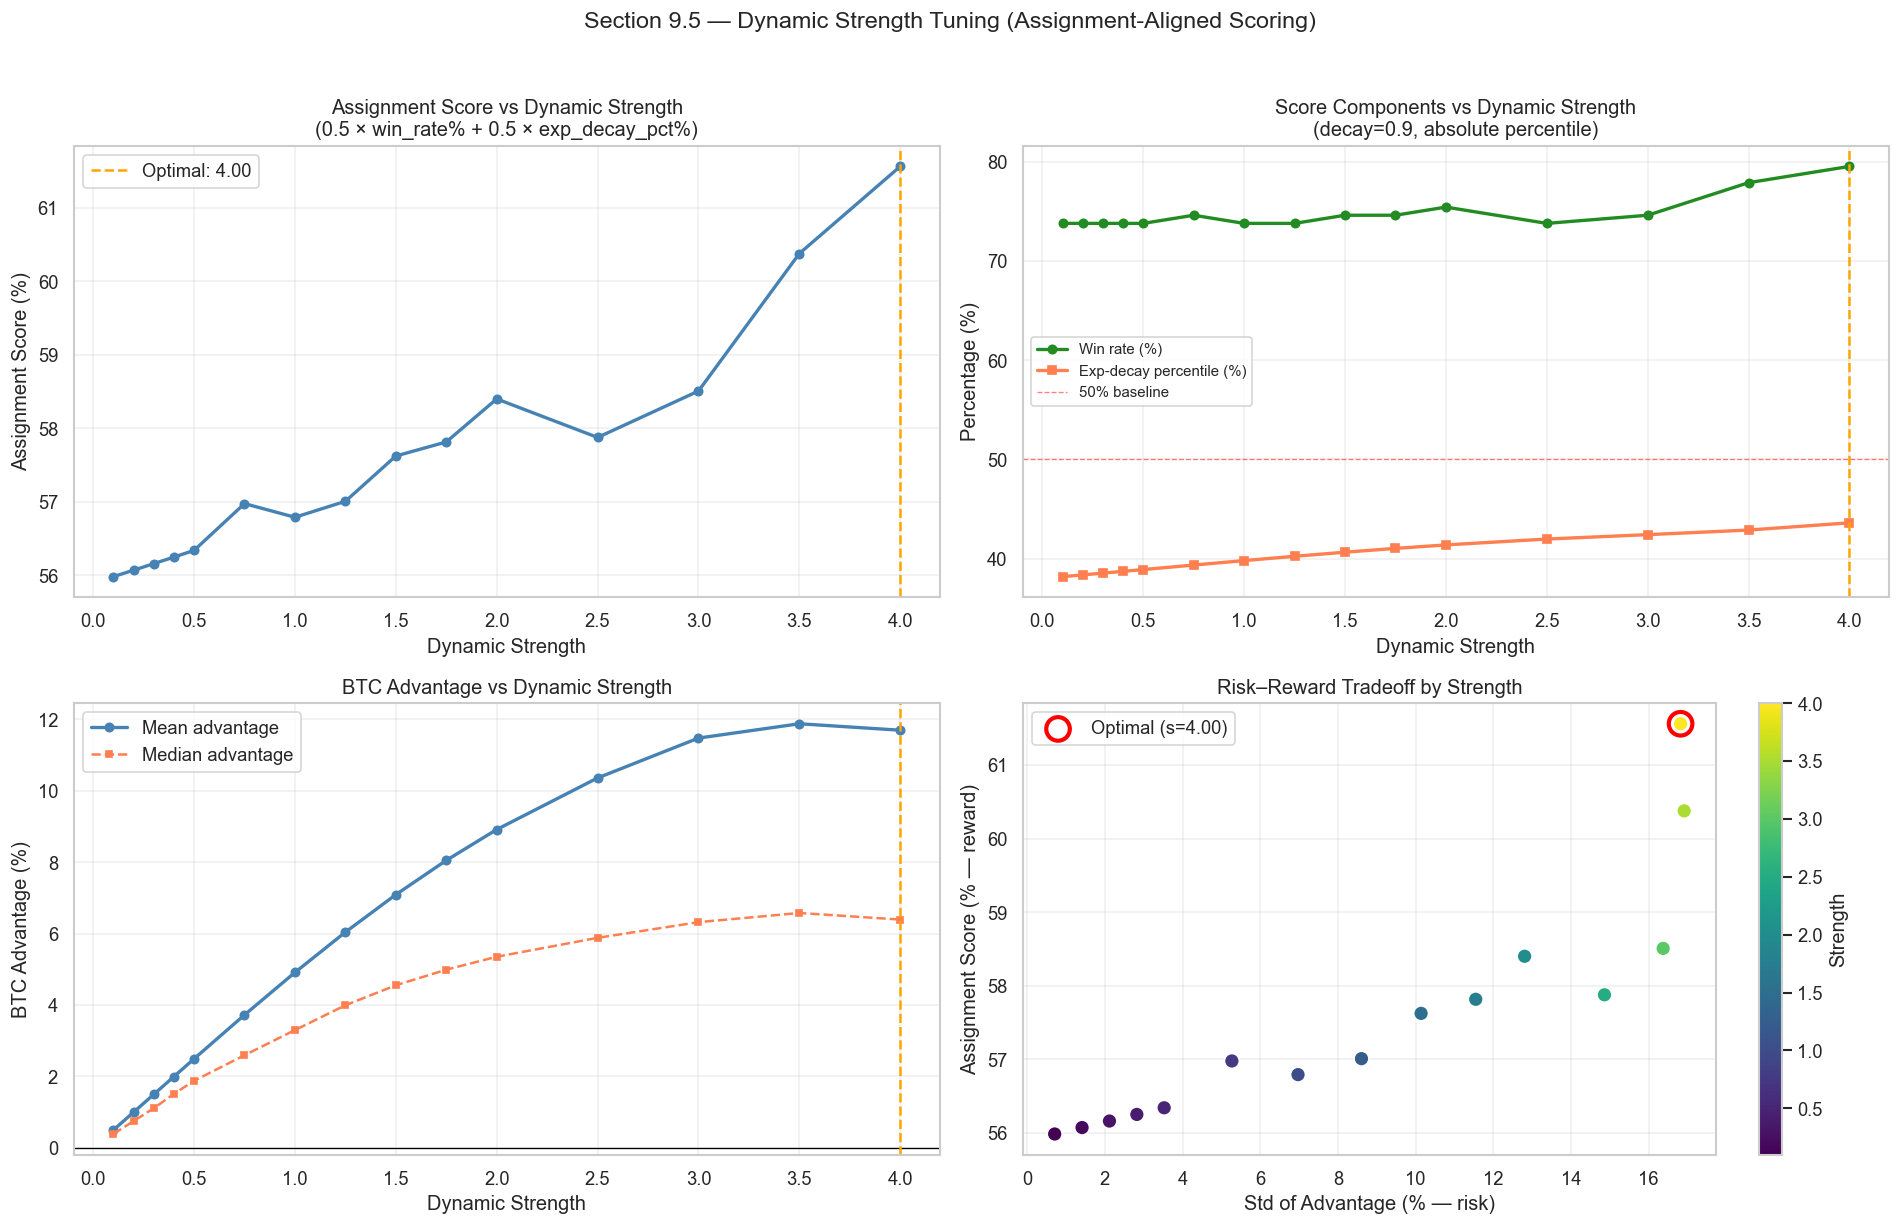


Recommended DYNAMIC_STRENGTH for model_development_template.py: 4.00
Expected assignment score: 61.56%


In [44]:
# --- 9.5b. Visualise strength tuning results ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
s_pdf = strength_df.to_pandas()
strengths = s_pdf["strength"]
best_s = best_row["strength"]

# (1) Assignment score vs strength (score = 0.5*win% + 0.5*exp_decay%)
ax = axes[0, 0]
ax.plot(strengths, s_pdf["score"], "o-", color="steelblue", lw=2, markersize=5)
ax.axvline(best_s, color="orange", ls="--", lw=1.5,
           label=f"Optimal: {best_s:.2f}")
ax.set_xlabel("Dynamic Strength")
ax.set_ylabel("Assignment Score (%)")
ax.set_title("Assignment Score vs Dynamic Strength\n(0.5 × win_rate% + 0.5 × exp_decay_pct%)")
ax.legend()
ax.grid(True, alpha=0.3)

# (2) Score components: win rate and exp-decay percentile
ax = axes[0, 1]
ax.plot(strengths, s_pdf["win_rate_pct"], "o-", color="forestgreen", lw=2,
        markersize=5, label="Win rate (%)")
ax.plot(strengths, s_pdf["exp_decay_percentile"], "s-", color="coral", lw=2,
        markersize=5, label="Exp-decay percentile (%)")
ax.axhline(50, color="red", ls="--", lw=0.8, alpha=0.5, label="50% baseline")
ax.axvline(best_s, color="orange", ls="--", lw=1.5)
ax.set_xlabel("Dynamic Strength")
ax.set_ylabel("Percentage (%)")
ax.set_title("Score Components vs Dynamic Strength\n(decay=0.9, absolute percentile)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# (3) Mean & median BTC advantage vs strength
ax = axes[1, 0]
ax.plot(strengths, s_pdf["mean_advantage"], "o-", color="steelblue", lw=2,
        markersize=5, label="Mean advantage")
ax.plot(strengths, s_pdf["median_advantage"], "s--", color="coral", lw=1.5,
        markersize=4, label="Median advantage")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(best_s, color="orange", ls="--", lw=1.5)
ax.set_xlabel("Dynamic Strength")
ax.set_ylabel("BTC Advantage (%)")
ax.set_title("BTC Advantage vs Dynamic Strength")
ax.legend()
ax.grid(True, alpha=0.3)

# (4) Risk-return: std vs score
ax = axes[1, 1]
scatter = ax.scatter(s_pdf["std_advantage"], s_pdf["score"],
                     c=strengths, cmap="viridis", s=80, edgecolor="white", zorder=3)
opt_idx = s_pdf["score"].idxmax()
ax.scatter(s_pdf.loc[opt_idx, "std_advantage"], s_pdf.loc[opt_idx, "score"],
           s=200, facecolors="none", edgecolors="red", linewidths=2.5, zorder=4,
           label=f"Optimal (s={best_s:.2f})")
ax.set_xlabel("Std of Advantage (% — risk)")
ax.set_ylabel("Assignment Score (% — reward)")
ax.set_title("Risk–Reward Tradeoff by Strength")
ax.legend()
ax.grid(True, alpha=0.3)
fig.colorbar(scatter, ax=ax, label="Strength")

plt.suptitle("Section 9.5 — Dynamic Strength Tuning (Assignment-Aligned Scoring)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "dynamic_strength_tuning.png", bbox_inches="tight")
plt.show()

print(f"\nRecommended DYNAMIC_STRENGTH for model_development_template.py: {best_s:.2f}")
print(f"Expected assignment score: {best_row['score']:.2f}%")

## 10. Summary Dashboard

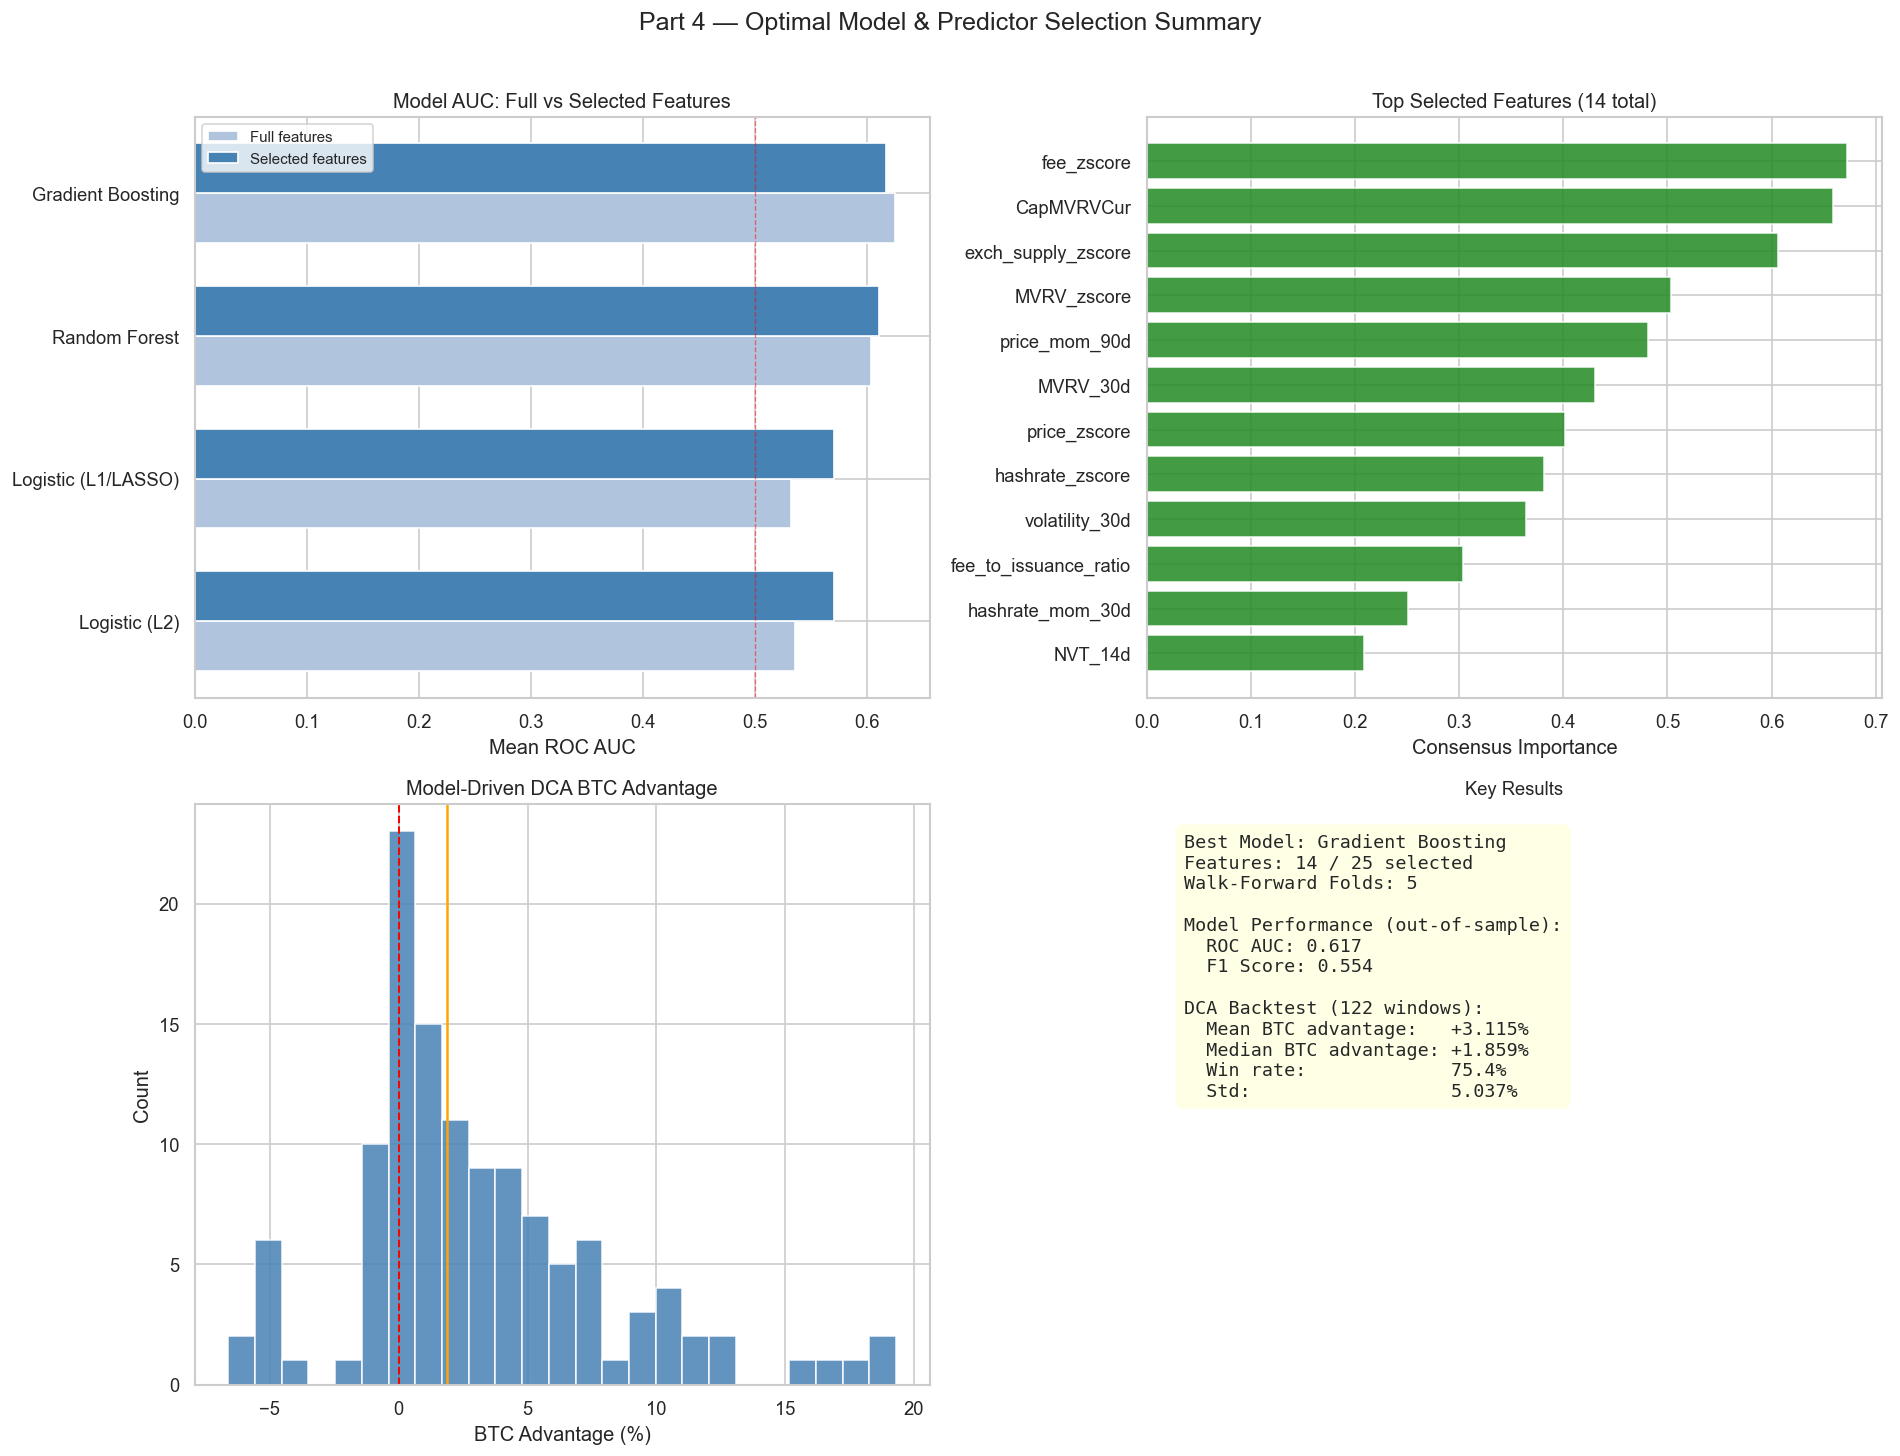

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- (1) Model comparison bar chart ---
ax = axes[0, 0]
comp_pdf = comparison.to_pandas().sort_values("reduced_auc", ascending=True)
y_pos = range(len(comp_pdf))
ax.barh(y_pos, comp_pdf["full_auc"], height=0.35, label="Full features", color="lightsteelblue", edgecolor="white")
ax.barh([y + 0.35 for y in y_pos], comp_pdf["reduced_auc"], height=0.35, label="Selected features", color="steelblue", edgecolor="white")
ax.set_yticks([y + 0.175 for y in y_pos])
ax.set_yticklabels(comp_pdf["model"])
ax.set_xlabel("Mean ROC AUC")
ax.set_title("Model AUC: Full vs Selected Features")
ax.legend(fontsize=9)
ax.axvline(0.5, color="red", ls="--", lw=0.8, alpha=0.5)

# --- (2) Top features ---
ax = axes[0, 1]
top_feats = importance_df.head(min(12, len(selected_features))).to_pandas()
ax.barh(top_feats["feature"][::-1], top_feats["consensus_score"][::-1],
        color="forestgreen", edgecolor="white", alpha=0.85)
ax.set_xlabel("Consensus Importance")
ax.set_title(f"Top Selected Features ({len(selected_features)} total)")

# --- (3) DCA advantage histogram ---
ax = axes[1, 0]
ax.hist(adv_vals, bins=25, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", ls="--", lw=1.2)
ax.axvline(np.median(adv_vals), color="orange", ls="-", lw=1.5)
ax.set_xlabel("BTC Advantage (%)")
ax.set_ylabel("Count")
ax.set_title("Model-Driven DCA BTC Advantage")

# --- (4) Summary text ---
ax = axes[1, 1]
ax.axis("off")
text_lines = [
    f"Best Model: {best_model_name}",
    f"Features: {len(selected_features)} / {len(FEATURE_COLS)} selected",
    f"Walk-Forward Folds: {N_SPLITS}",
    f"",
    f"Model Performance (out-of-sample):",
    f"  ROC AUC: {comparison.filter(pl.col('model') == best_model_name)['reduced_auc'][0]:.3f}",
    f"  F1 Score: {comparison.filter(pl.col('model') == best_model_name)['reduced_f1'][0]:.3f}",
    f"",
    f"DCA Backtest ({len(dca_res_df)} windows):",
    f"  Mean BTC advantage:   {adv.mean():+.3f}%",
    f"  Median BTC advantage: {adv.median():+.3f}%",
    f"  Win rate:             {(adv > 0).mean()*100:.1f}%",
    f"  Std:                  {adv.std():.3f}%",
]
ax.text(0.05, 0.95, "\n".join(text_lines),
        transform=ax.transAxes, fontsize=11,
        verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))
ax.set_title("Key Results", fontsize=11)

plt.suptitle("Part 4 — Optimal Model & Predictor Selection Summary", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_selection_summary.png", bbox_inches="tight")
plt.show()

## 11. Conclusions

### Model Selection
- Walk-forward time-series CV across 4 classifiers identified the best-performing model
- Reduced feature set retains (or improves) AUC, confirming that many raw features are redundant

### Feature Selection
- Three independent methods (LASSO, Random Forest, Gradient Boosting) converged on a consensus ranking
- Valuation z-scores (MVRV, NVT, composite) consistently rank among top predictors
- Price momentum and exchange flow features provide complementary signal
- Mining and supply features tend to have lower standalone predictive power

### Dynamic Strength Tuning
- The exponential multiplier strength parameter significantly impacts the risk–return profile
- Lower strength values improve consistency (higher win rate) at the cost of smaller per-window gains
- Higher strength values amplify both wins and losses, reducing the composite score
- The optimal strength balances win rate against the exp-decay percentile penalty

### DCA Integration
- Model-driven allocation (probability-based multiplier) produces a budget-neutral DCA variant
- The tuned dynamic strength should be applied in `model_development_template.py` as `DYNAMIC_STRENGTH`
- Results should be compared against the heuristic z-score approach from Part 2

### Caveats
- All evaluation is out-of-sample via walk-forward CV, but past performance does not guarantee future results
- The target (above-median forward return) uses an expanding median that adapts over time
- Feature engineering uses rolling lookbacks that require a 2-year warmup period
- Strength tuning uses the same out-of-sample predictions from Section 8, so the grid search does not introduce additional data leakage